## importing data

In [1]:
import pandas as pd

train_df = pd.read_csv(r"../data/cleaned/train_cleaned.csv")

train_df.head()

,alt,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,...,SmFan,SmLPC,SmHPC,phi,unit,cycle,Fc,hs,HPT_eff_mod,RUL
0,3013.0,0.376362,70.311996,522.314770,618.288596,1470.469798,1849.620676,1269.275585,19.432070,14.484611,...,15.879671,9.925145,25.648148,42.152925,1.0,1.0,1.0,1.0,-0.000604,99
1,3020.0,0.376866,70.311996,522.327145,618.296355,1470.415593,1849.519871,1269.177159,19.431385,14.484683,...,15.888485,9.916771,25.651719,42.150936,1.0,1.0,1.0,1.0,-0.000604,99
2,3025.0,0.377685,70.311996,522.371840,618.336514,1470.453853,1849.566139,1269.167353,19.435163,14.488224,...,15.902505,9.911186,25.652633,42.151475,1.0,1.0,1.0,1.0,-0.000604,99
3,3035.0,0.376992,70.399887,522.282418,618.302173,1470.650929,1850.195069,1269.518670,19.426003,14.477632,...,15.889568,9.927131,25.632641,42.169738,1.0,1.0,1.0,1.0,-0.000604,99
4,3043.0,0.377622,70.399887,522.300605,618.345228,1470.640421,1849.950988,1269.253972,19.427484,14.478114,...,15.895957,9.916870,25.644562,42.160144,1.0,1.0,1.0,1.0,-0.000604,99


In [2]:
train_df.shape

(4906636, 38)

In [3]:
train_df.columns

Index(['alt', 'Mach', 'TRA', 'T2', 'T24', 'T30', 'T48', 'T50', 'P15', 'P2',
       'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf', 'T40', 'P30',
       'P45', 'W21', 'W22', 'W25', 'W31', 'W32', 'W48', 'W50', 'SmFan',
       'SmLPC', 'SmHPC', 'phi', 'unit', 'cycle', 'Fc', 'hs', 'HPT_eff_mod',
       'RUL'],
      dtype='str')

Determine window size to get trends

In [4]:
cycle_per_unit = train_df.groupby("unit")["cycle"].max()

In [5]:
print(cycle_per_unit)

unit
1.0    100.0
2.0     75.0
3.0    100.0
4.0     95.0
5.0     89.0
6.0     94.0
Name: cycle, dtype: float64


Based on 2.0 unit the mininum cycles is 75.5 so the good area for window size is from 5 to 15

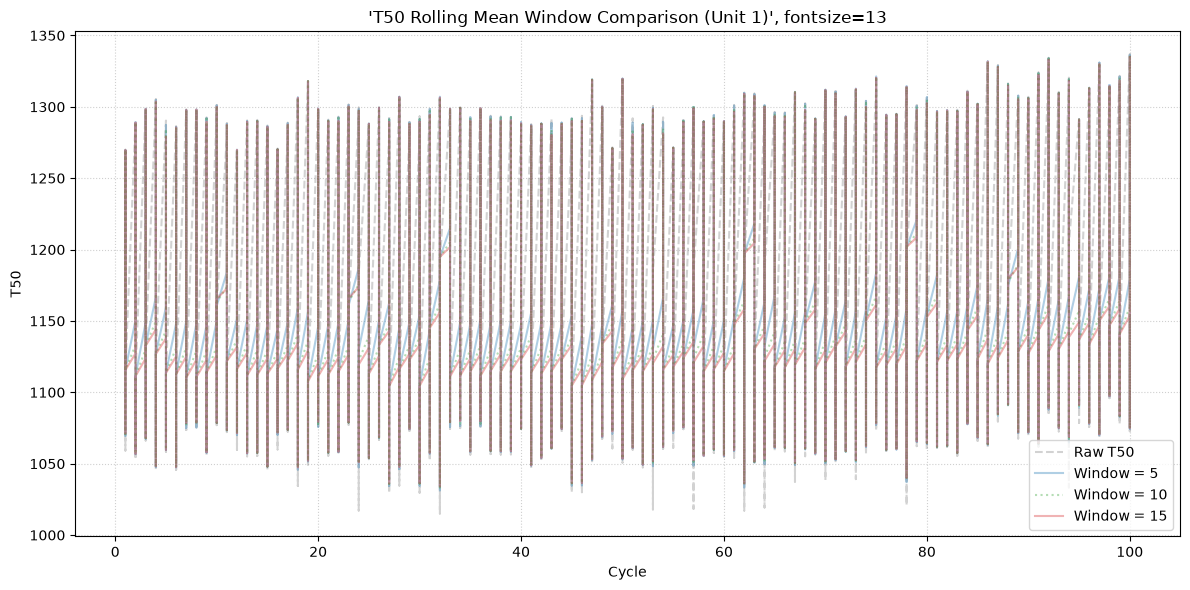

In [6]:
import matplotlib.pyplot as plt

windows = [5, 10, 15]
temp_df = train_df.copy()
units = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]


for w in windows:
    
    temp_df[f"T50_smooth_{w}"] = temp_df.groupby("unit")["T50"].transform(
        lambda x: x.rolling(window=w, min_periods=1).mean()
    )
    

unit_data = temp_df[temp_df["unit"] == 1]

plt.figure(figsize=(12, 6))

plt.plot(unit_data["cycle"], unit_data["T50"],
         label="Raw T50", alpha=0.35, color="gray", linestyle="--")

plt.plot(unit_data["cycle"], unit_data["T50_smooth_5"],
         label="Window = 5", alpha=0.35, color="#1f77b4", linestyle="-")

plt.plot(unit_data["cycle"], unit_data["T50_smooth_10"],
         label="Window = 10", alpha=0.35, color="#2ca02c", linestyle="dotted")
    
plt.plot(unit_data["cycle"], unit_data["T50_smooth_15"],
         label="Window = 15", alpha=0.35, color="#d62728", linestyle="solid")

plt.title("'T50 Rolling Mean Window Comparison (Unit 1)', fontsize=13")
plt.xlabel("Cycle")    
plt.ylabel("T50")    

plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

Collecting data based on one trip each time

In [7]:
exception_cols = ["unit", "cycle", "Fc", "hs", "RUL"]
first_cols = ["Fc", "hs", "RUL"]

targeted_cols = [col for col in train_df.columns if col not in exception_cols]

agg_dict = {}
for col in targeted_cols:
    agg_dict[col] = ["mean", "std"]
for col in first_cols:
    agg_dict[col] = ["first"]

new_df = train_df.groupby(["unit", "cycle"]).agg(agg_dict)

In [8]:
new_df

alt                   Mach                  TRA  \
                    mean          std      mean       std       mean   
unit cycle                                                             
1.0  1.0     8757.580258  2431.078947  0.473754  0.063170  53.426549   
     2.0     9888.501717  2984.513367  0.484357  0.065859  52.167015   
     3.0     7578.456209  2240.489275  0.407481  0.084509  49.449162   
     4.0     8074.442717  3067.633192  0.451582  0.058257  50.406733   
     5.0    10441.229588  4056.651136  0.483761  0.091690  52.665702   
...                  ...          ...       ...       ...        ...   
6.0  90.0   14608.593805  5896.256221  0.529422  0.072582  62.244711   
     91.0   11820.501929  4273.678420  0.485740  0.101215  54.438461   
     92.0   16749.683661  8386.695738  0.545193  0.131620  60.439984   
     93.0   14531.760583  6149.916985  0.537826  0.079334  61.710040   
     94.0   14507.113867  5752.136641  0.532115  0.105839  56.377967   

                               T2                    T24             ...  \
                  std        mean        std        mean        std  ...   
unit cycle                                                           ...   
1.0  1.0    15.810619  509.618593   4.311643  585.581207  15.419781  ...   
     2.0    15.805545  506.383588   5.641520  580.523902  15.513002  ...   
     3.0    13.955304  508.573118   3.548465  581.192859  14.843815  ...   
     4.0    19.235098  510.085909   7.029964  583.081949  19.090002  ...   
     5.0    18.562168  504.551834   7.766134  578.806006  16.676908  ...   
...               ...         ...        ...         ...        ...  ...   
6.0  90.0   23.248755  492.907219  15.212145  574.753226  24.740911  ...   
     91.0   13.349567  499.704868   7.502727  575.948845  13.336174  ...   
     92.0   21.973434  487.032919  19.828599  566.240133  22.462958  ...   
     93.0   21.433806  494.079146  15.450481  575.807817  21.672636  ...   
     94.0   15.881235  494.004077  12.486902  570.987196  16.366077  ...   

               SmLPC      SmHPC                  phi           HPT_eff_mod  \
                 std       mean       std       mean       std        mean   
unit cycle                                                                   
1.0  1.0    0.844486  28.938417  2.330002  37.907514  2.870055   -0.000604   
     2.0    0.837932  29.262052  2.347559  37.468438  2.873253   -0.000528   
     3.0    0.767393  29.213680  1.976865  37.472968  2.468808   -0.000794   
     4.0    1.055207  29.350810  2.905313  37.380182  3.553571   -0.000538   
     5.0    0.999292  29.249906  2.677621  37.426093  3.239193   -0.000637   
...              ...        ...       ...        ...       ...         ...   
6.0  90.0   1.154614  27.482211  3.507149  39.165449  4.185077   -0.014499   
     91.0   0.581038  28.051041  1.702108  38.514343  2.196831   -0.015131   
     92.0   1.049330  27.836859  2.981185  38.644882  3.539924   -0.016020   
     93.0   1.061455  27.325109  2.949698  39.317953  3.620079   -0.016867   
     94.0   0.751873  27.969837  2.022693  38.535267  2.552156   -0.017792   

                   Fc    hs   RUL  
            std first first first  
unit cycle                         
1.0  1.0    0.0   1.0   1.0    99  
     2.0    0.0   1.0   1.0    98  
     3.0    0.0   1.0   1.0    97  
     4.0    0.0   1.0   1.0    96  
     5.0    0.0   1.0   1.0    95  
...         ...   ...   ...   ...  
6.0  90.0   0.0   2.0   0.0     4  
     91.0   0.0   2.0   0.0     3  
     92.0   0.0   2.0   0.0     2  
     93.0   0.0   2.0   0.0     1  
     94.0   0.0   2.0   0.0     0  

[553 rows x 69 columns]

In [9]:
new_df.columns

MultiIndex([(        'alt',  'mean'),
            (        'alt',   'std'),
            (       'Mach',  'mean'),
            (       'Mach',   'std'),
            (        'TRA',  'mean'),
            (        'TRA',   'std'),
            (         'T2',  'mean'),
            (         'T2',   'std'),
            (        'T24',  'mean'),
            (        'T24',   'std'),
            (        'T30',  'mean'),
            (        'T30',   'std'),
            (        'T48',  'mean'),
            (        'T48',   'std'),
            (        'T50',  'mean'),
            (        'T50',   'std'),
            (        'P15',  'mean'),
            (        'P15',   'std'),
            (         'P2',  'mean'),
            (         'P2',   'std'),
            (        'P21',  'mean'),
            (        'P21',   'std'),
            (        'P24',  'mean'),
            (        'P24',   'std'),
            (       'Ps30',  'mean'),
            (       'Ps30',   'std'),
            

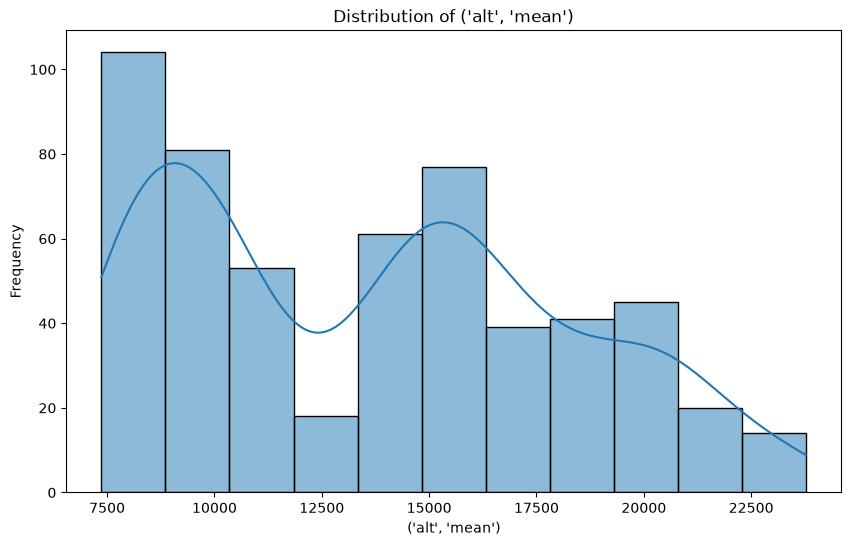

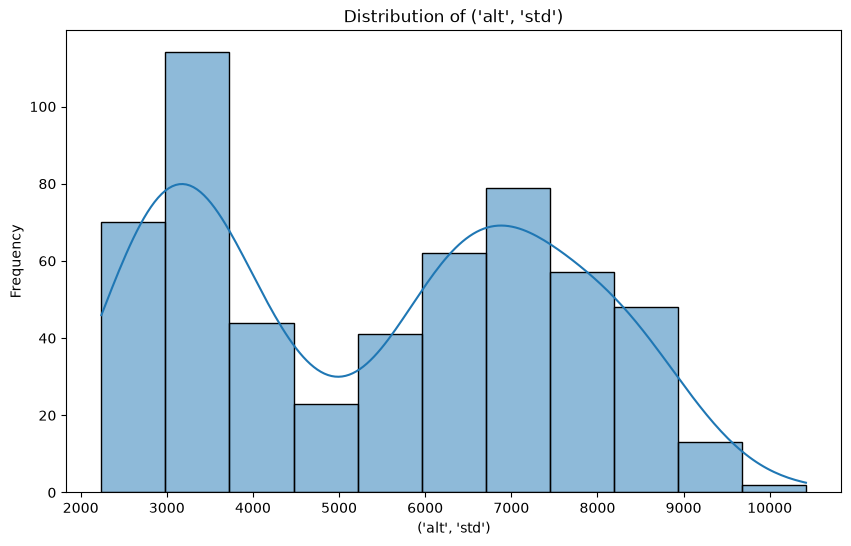

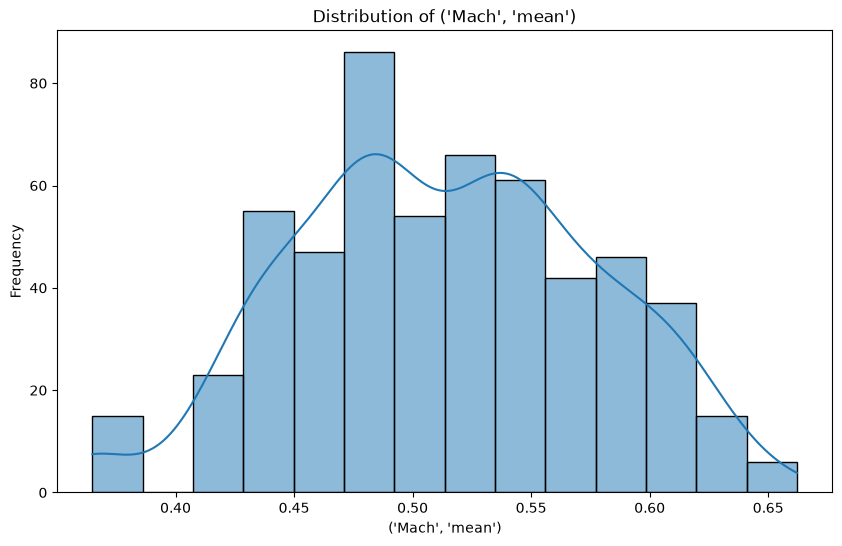

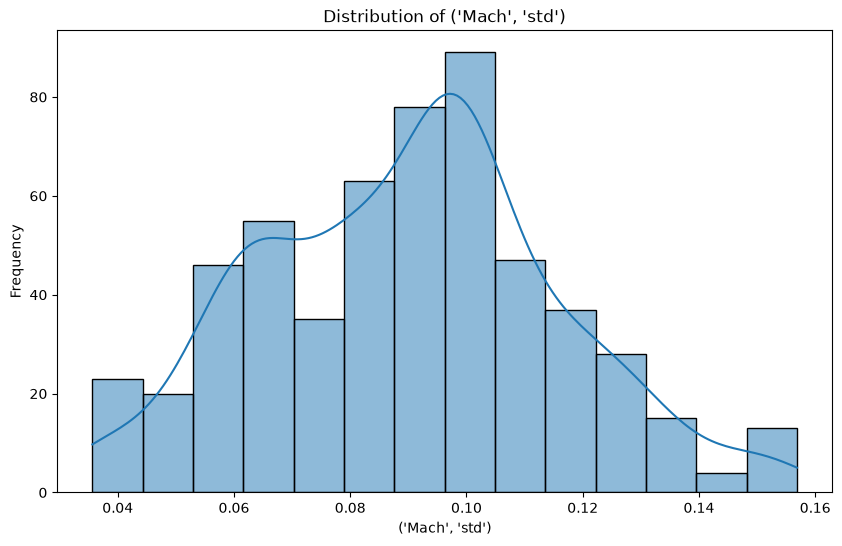

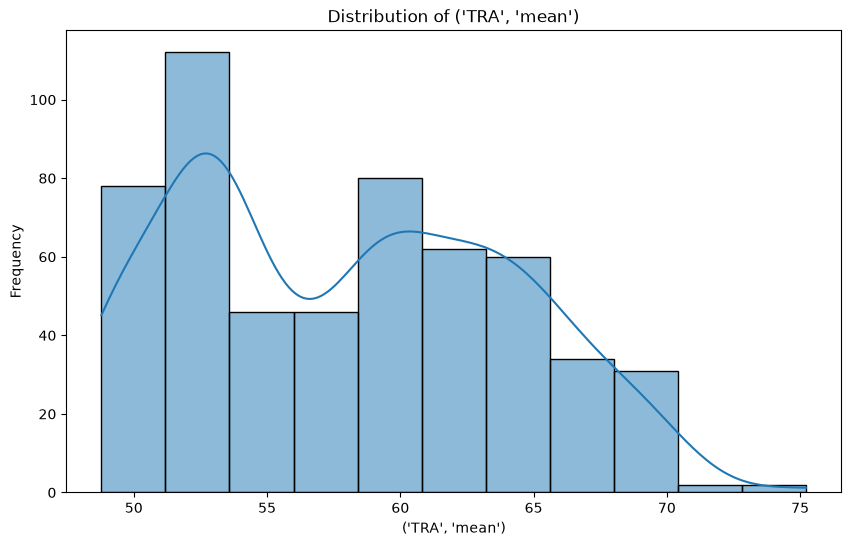

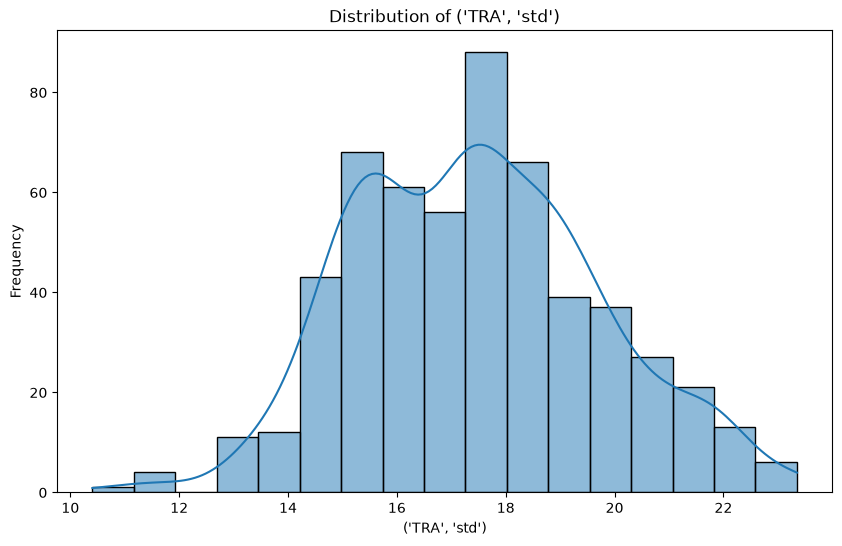

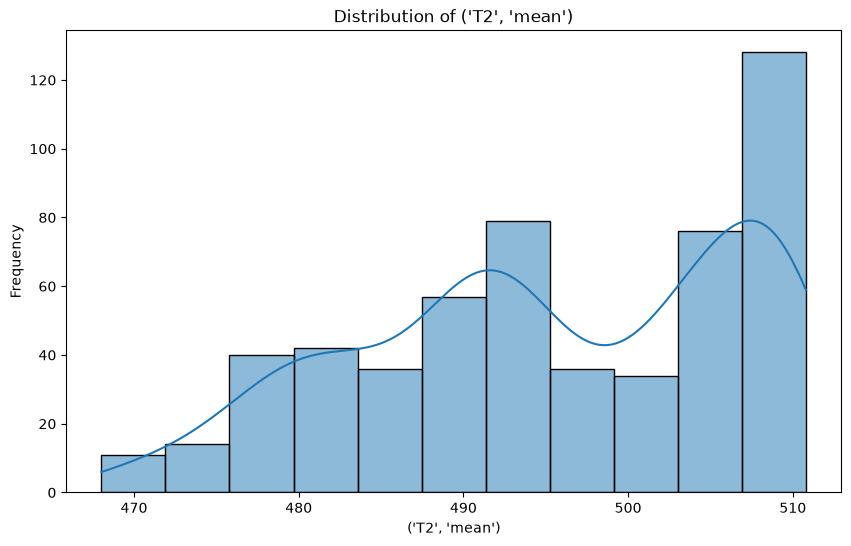

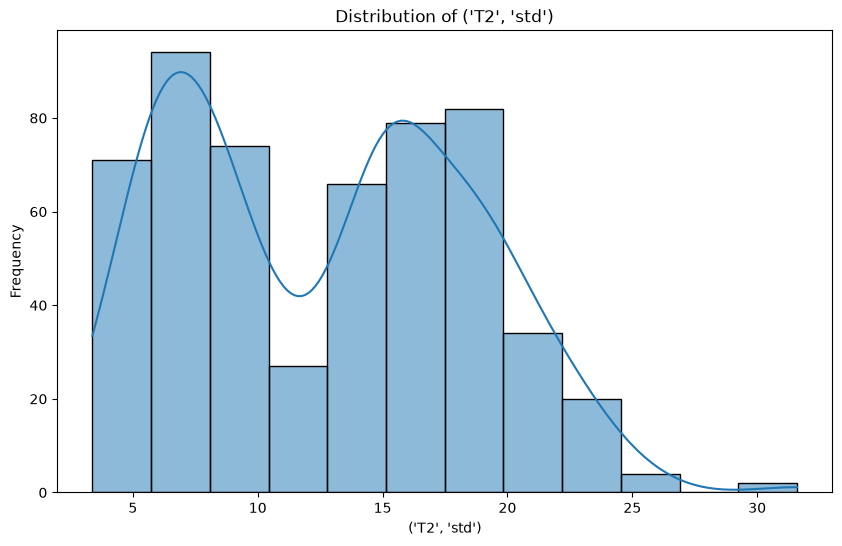

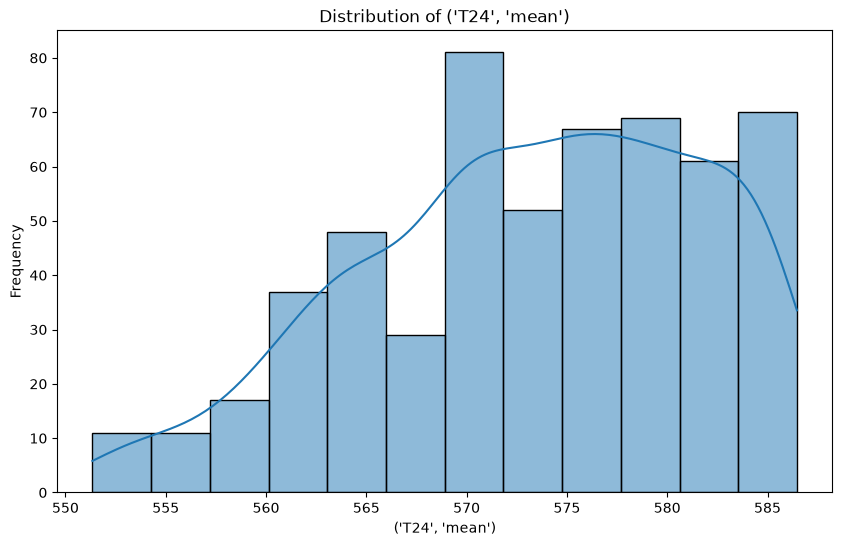

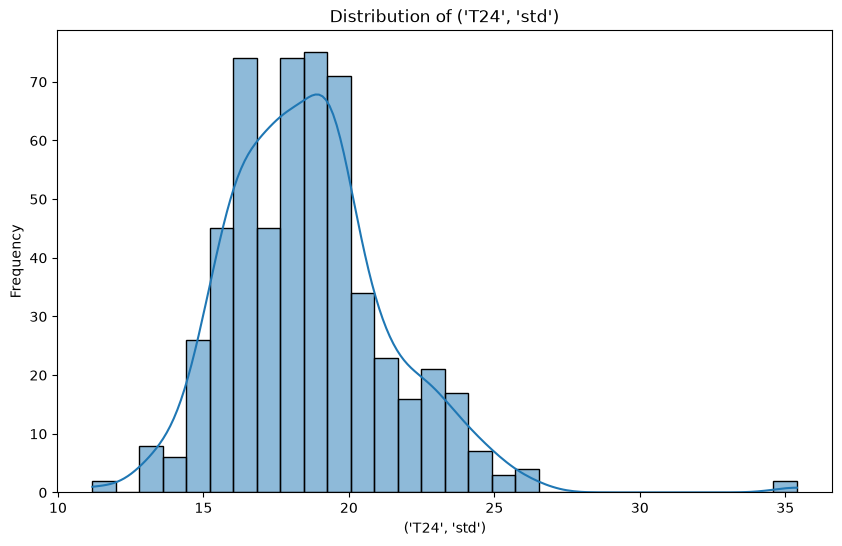

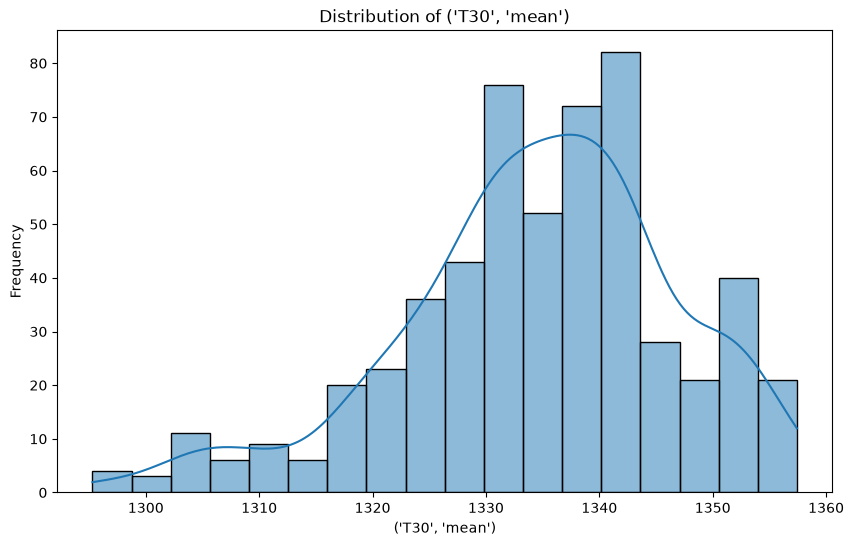

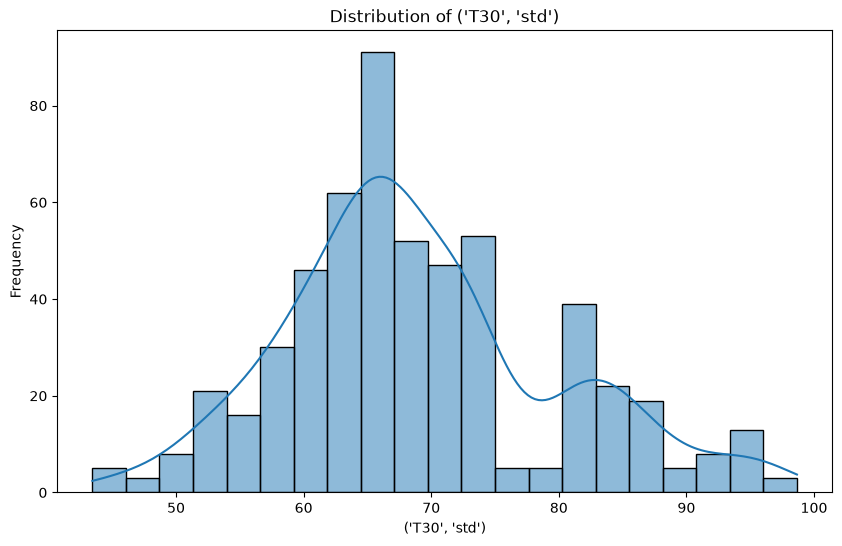

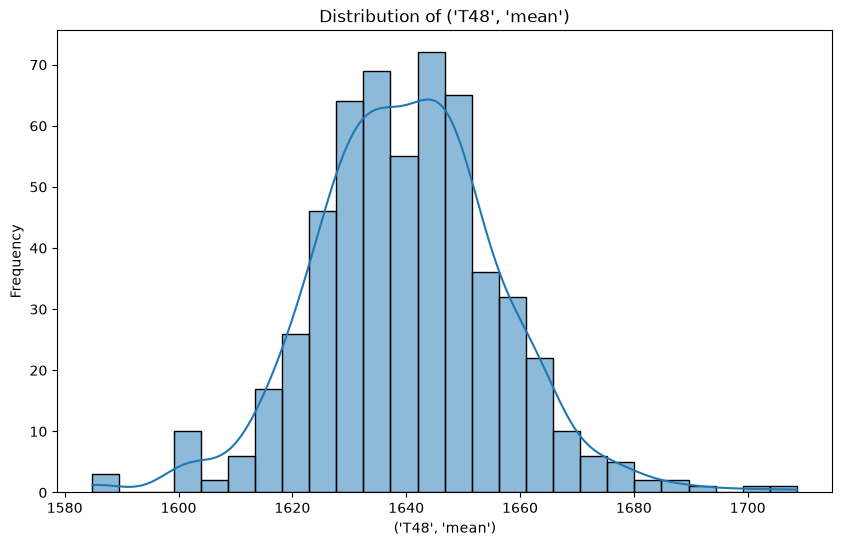

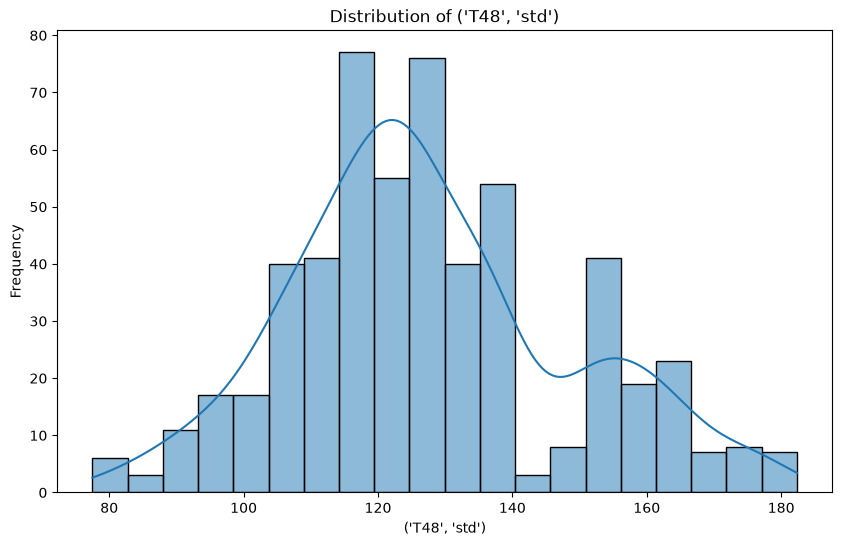

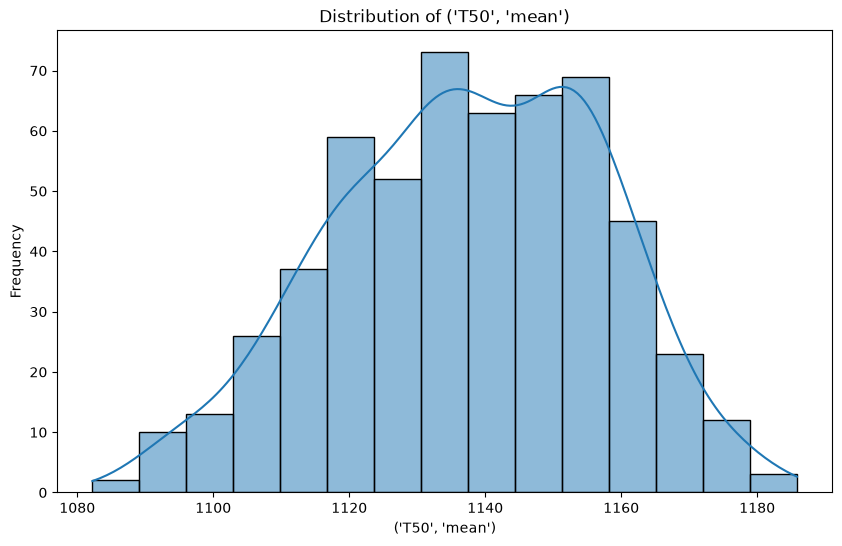

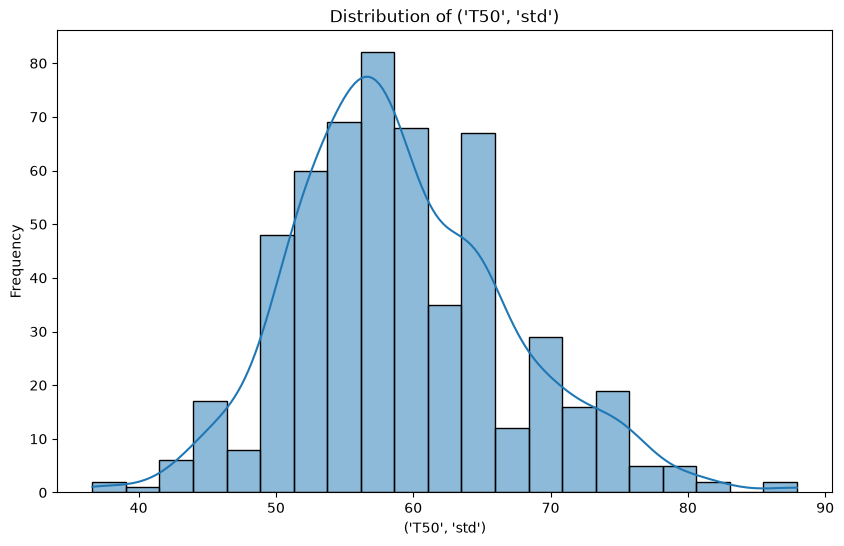

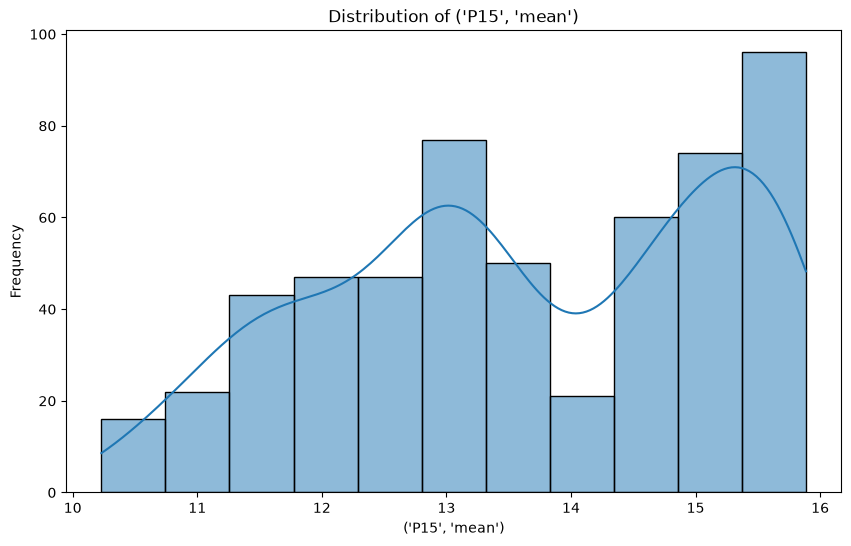

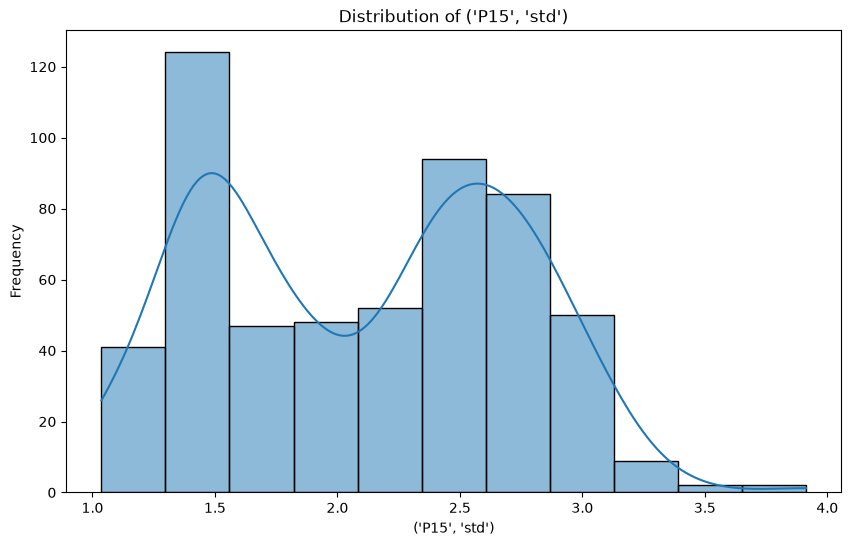

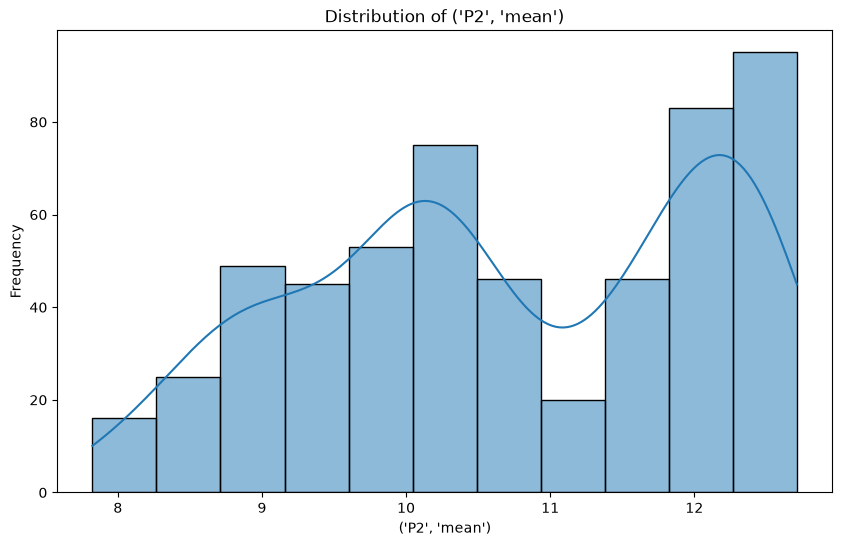

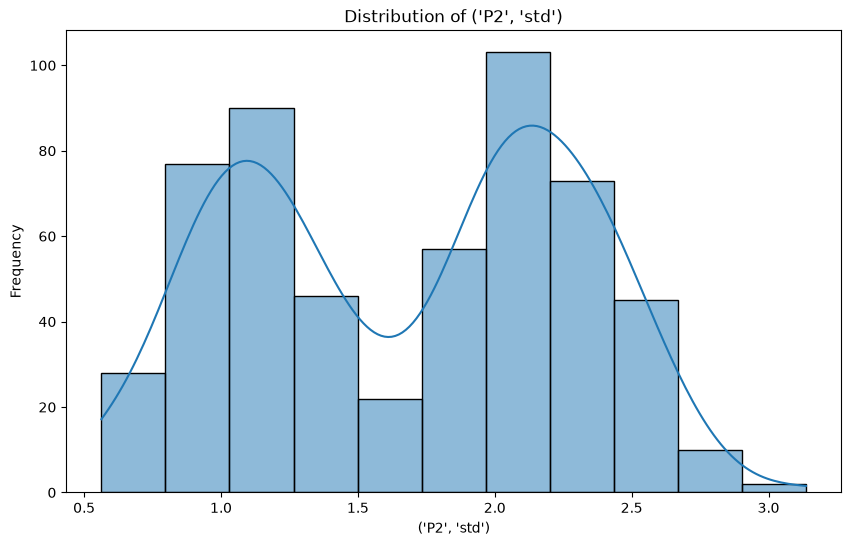

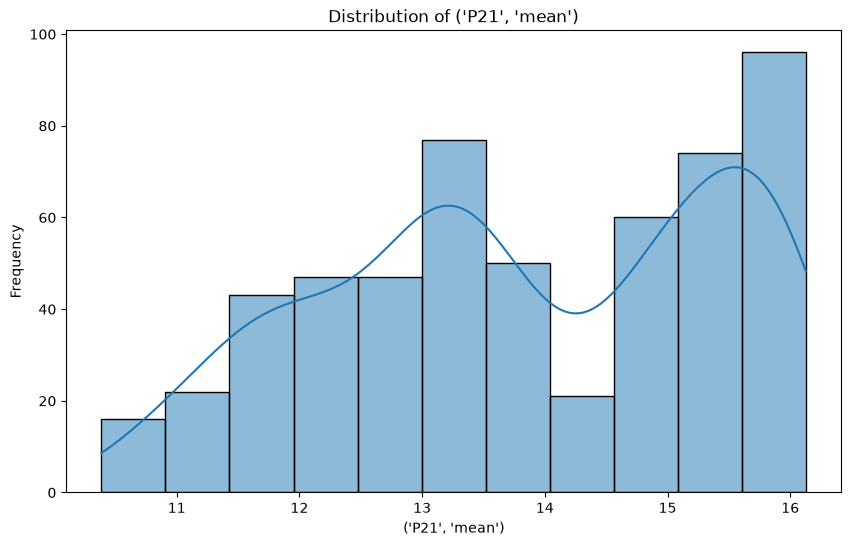

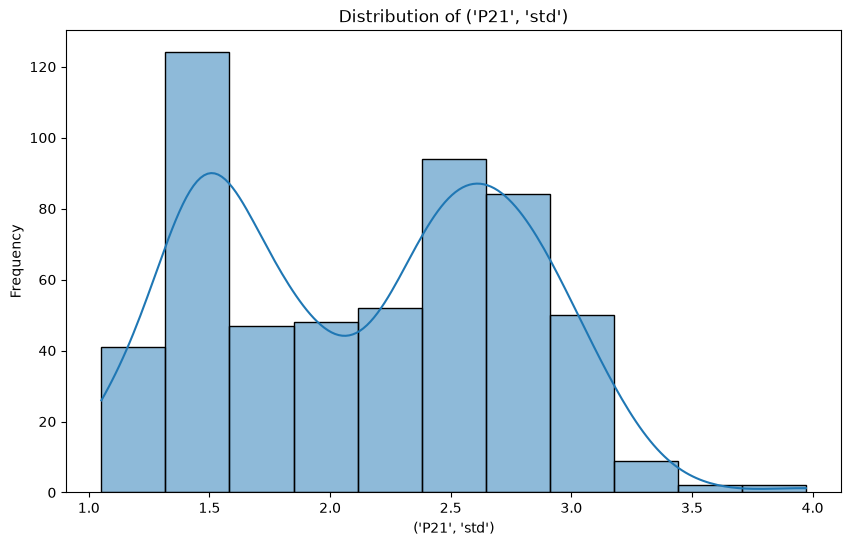

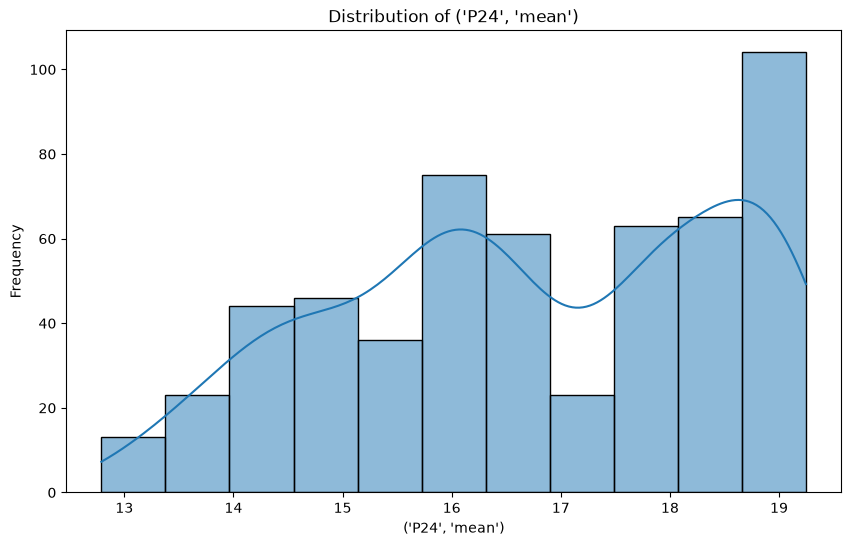

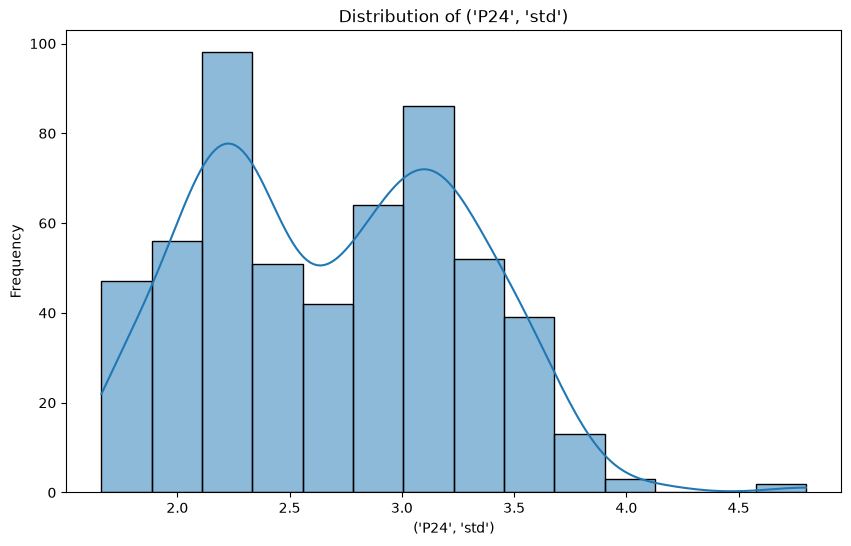

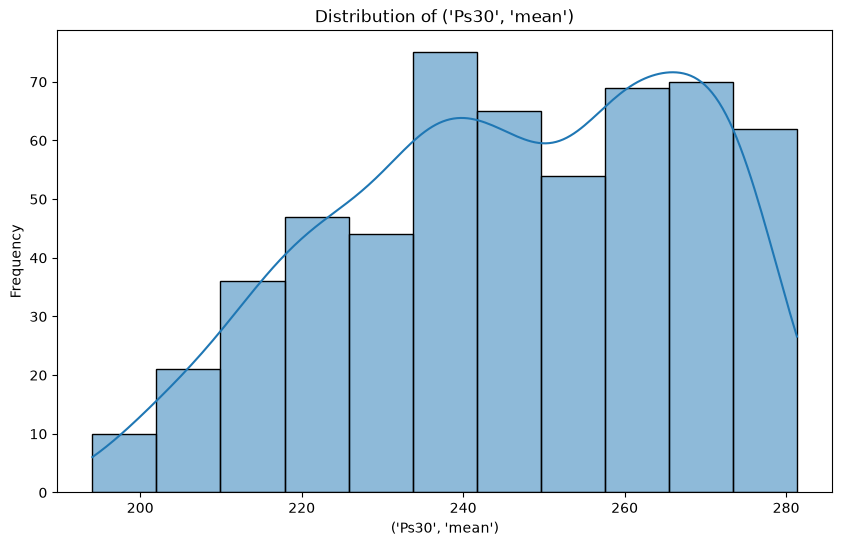

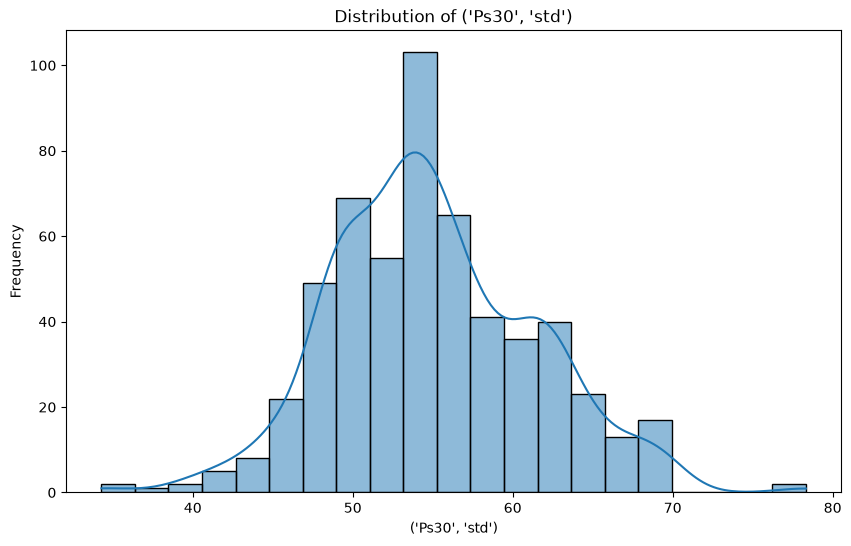

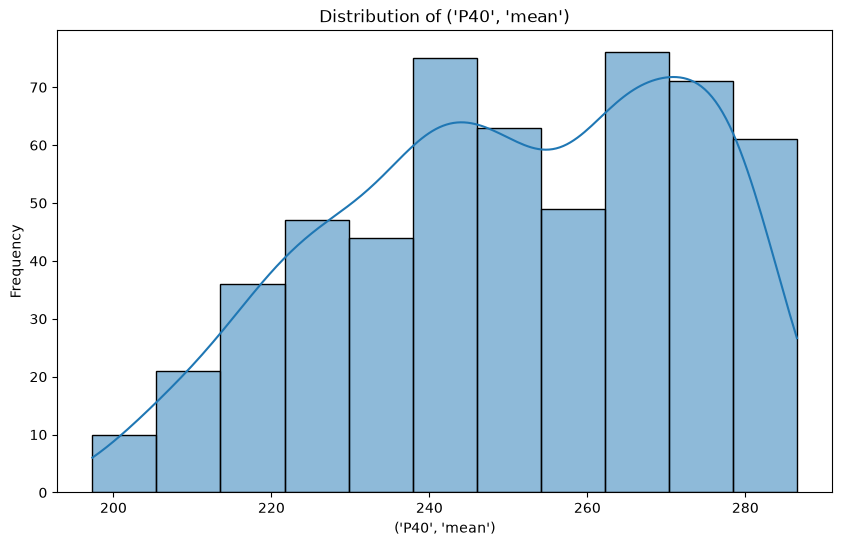

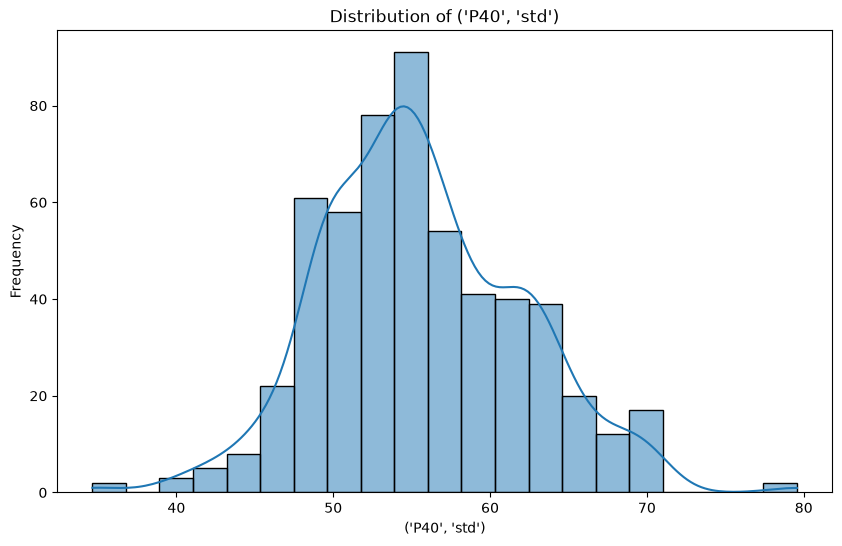

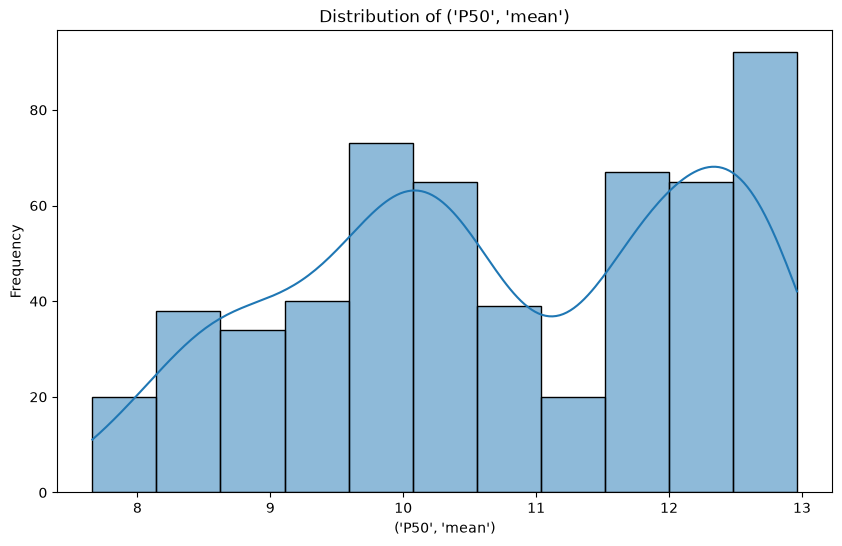

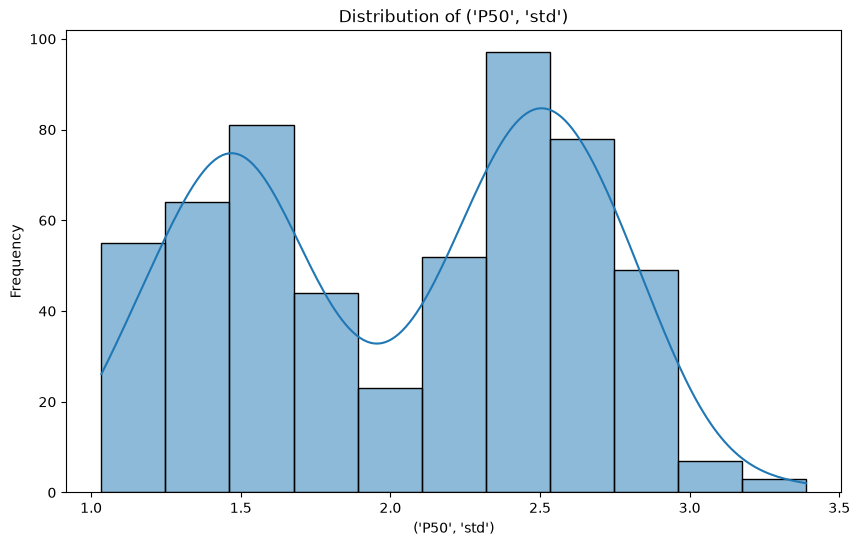

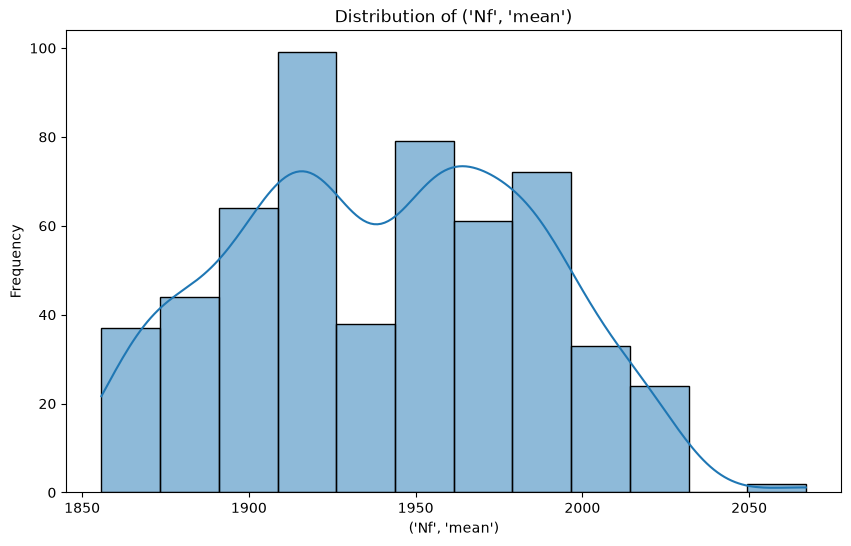

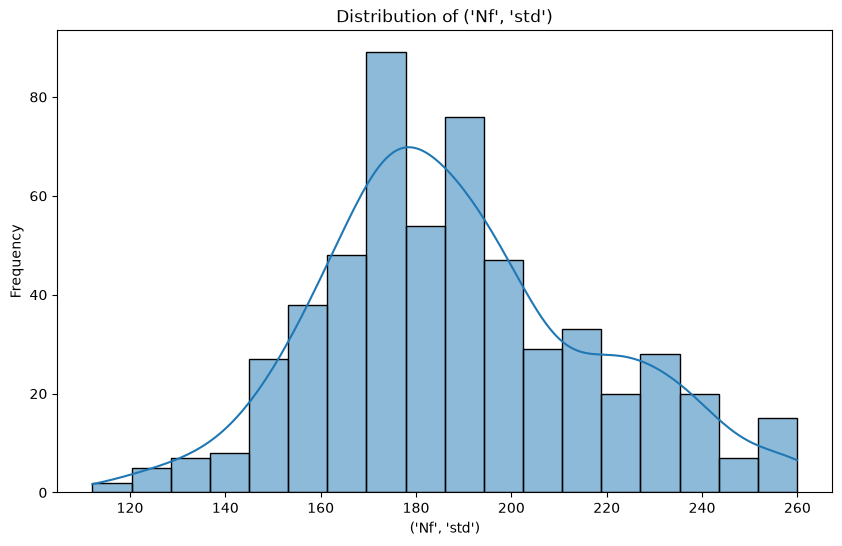

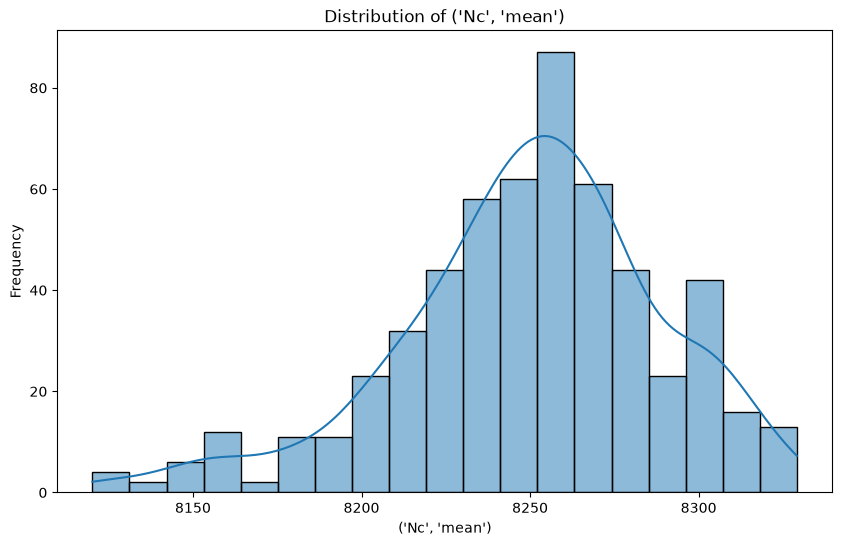

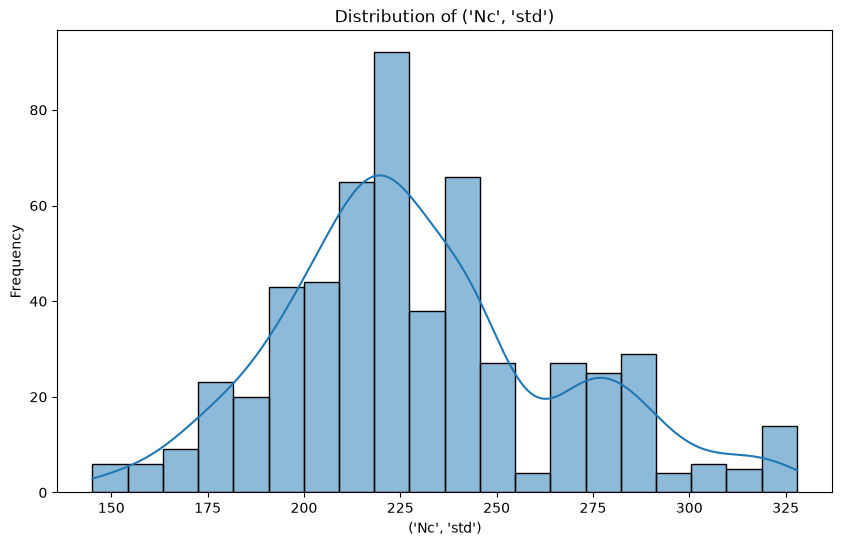

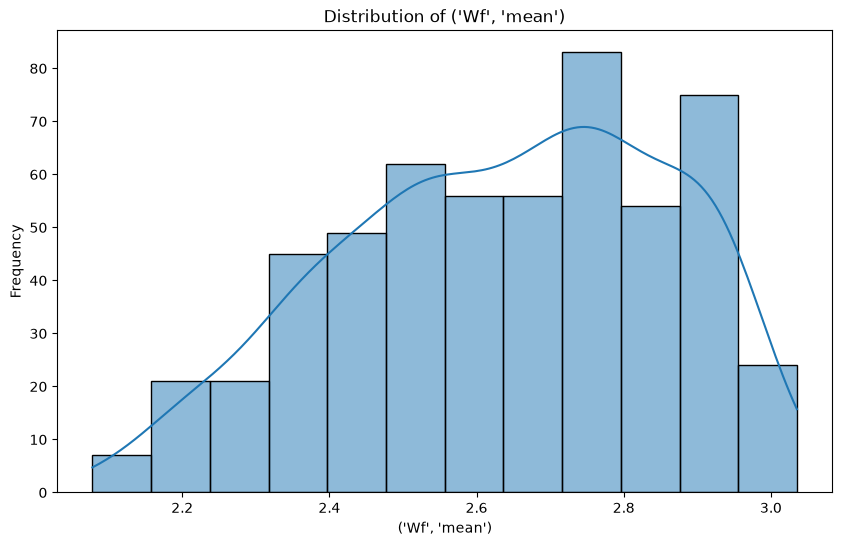

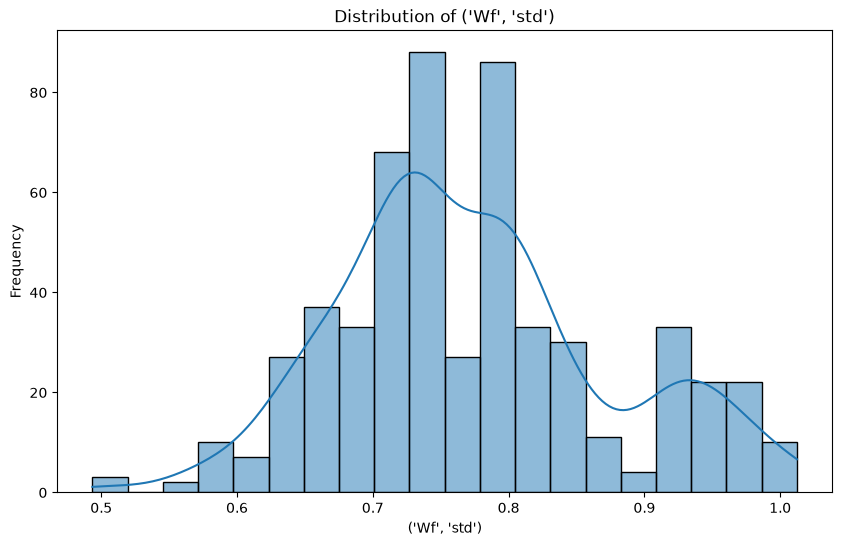

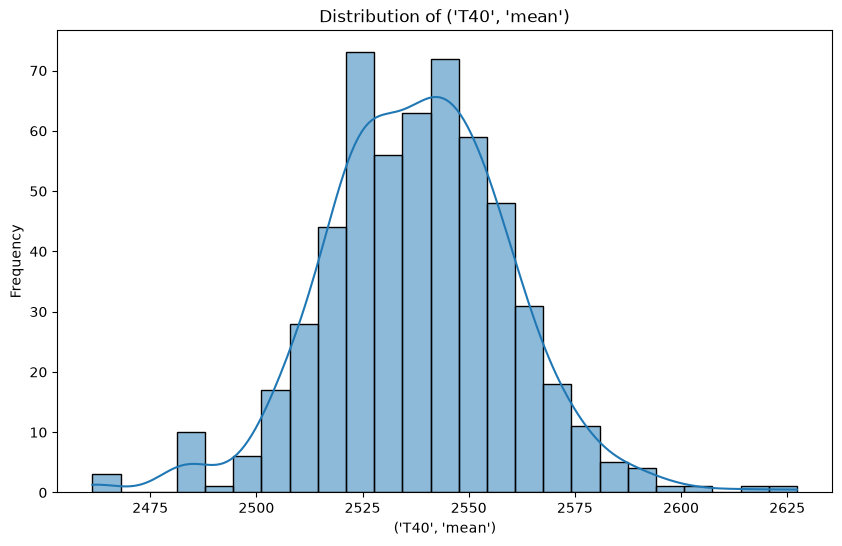

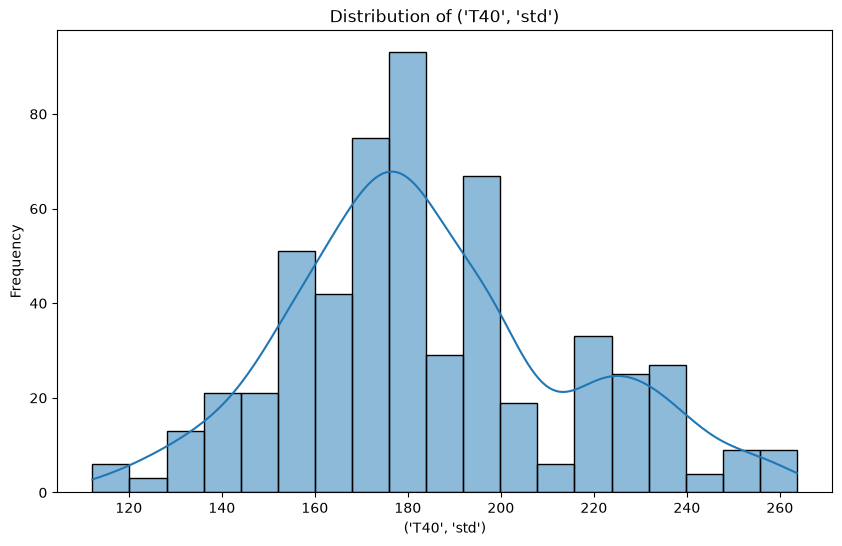

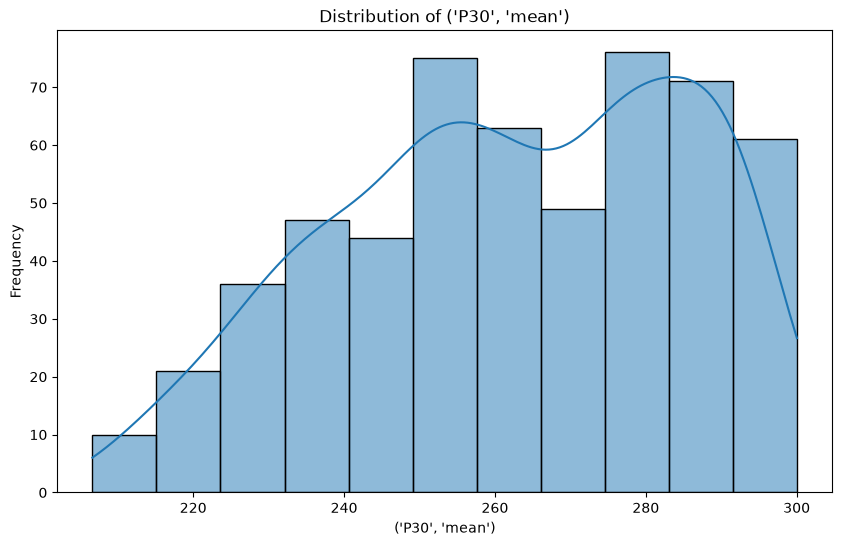

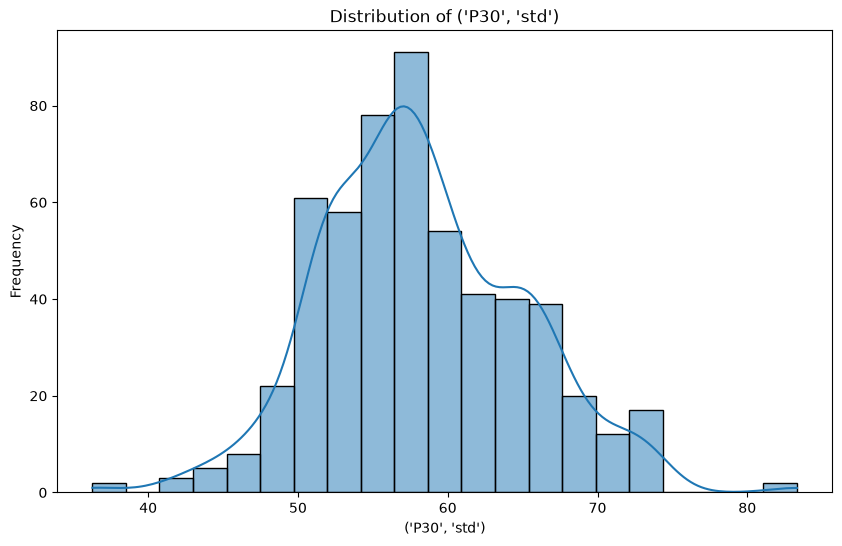

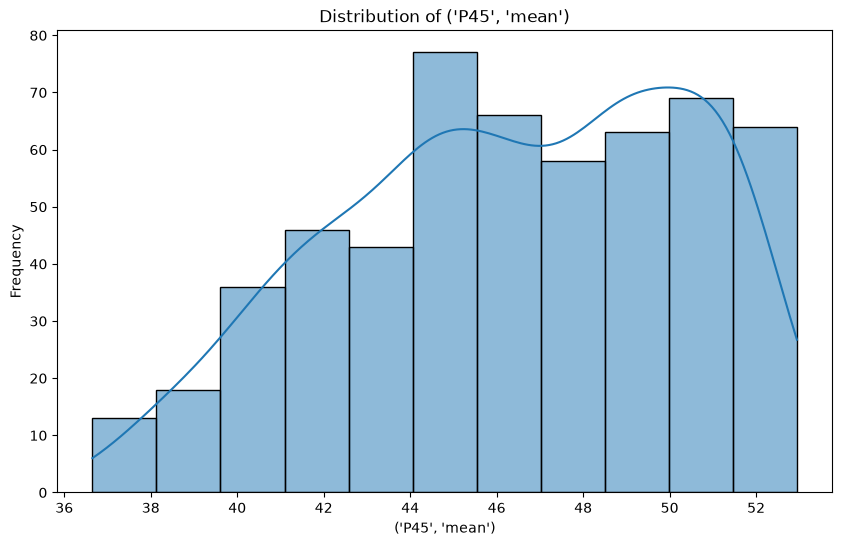

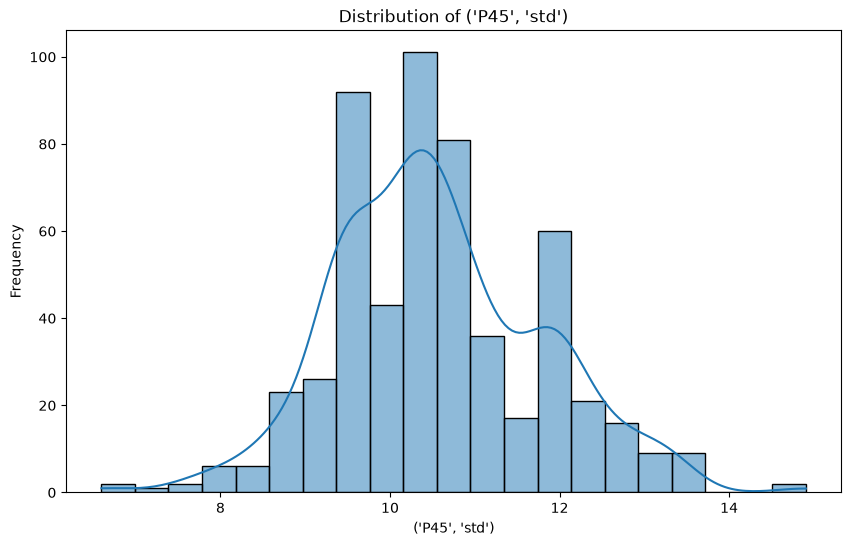

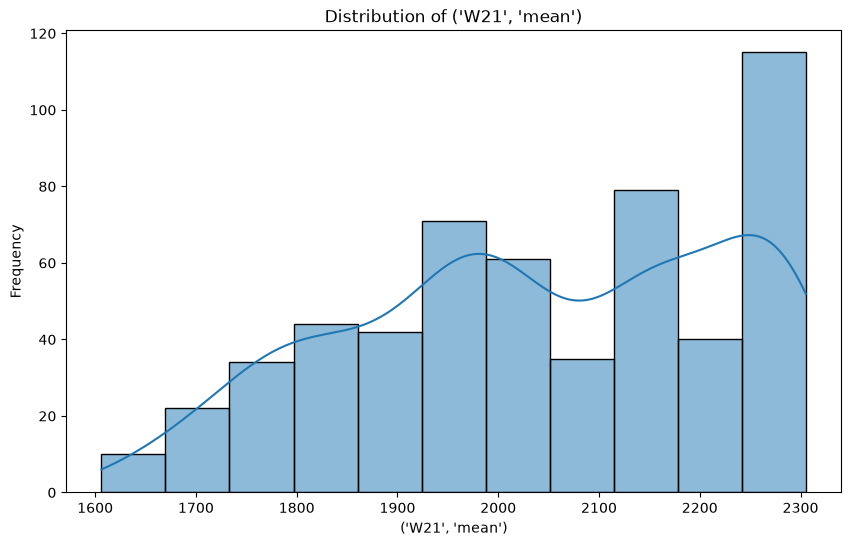

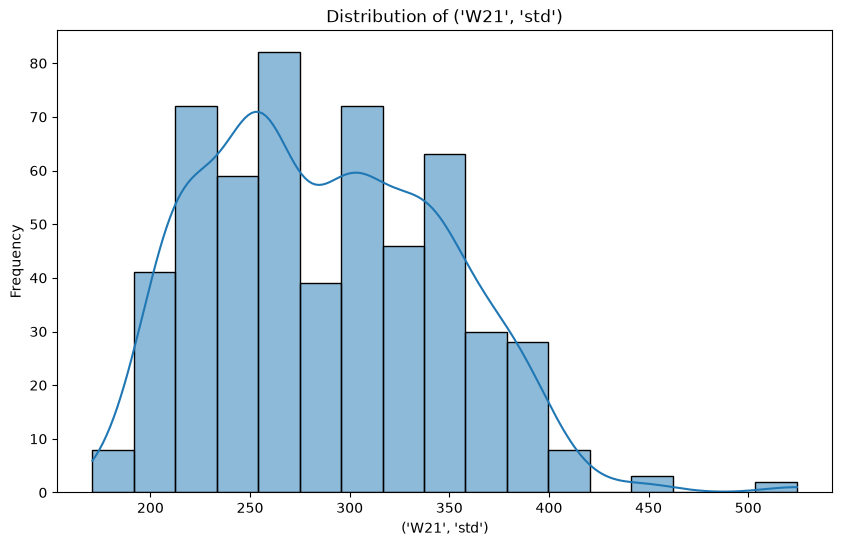

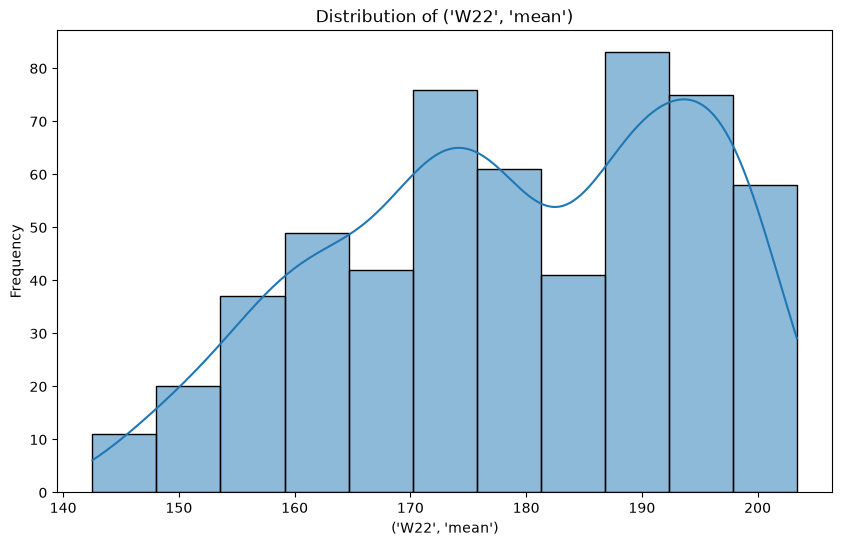

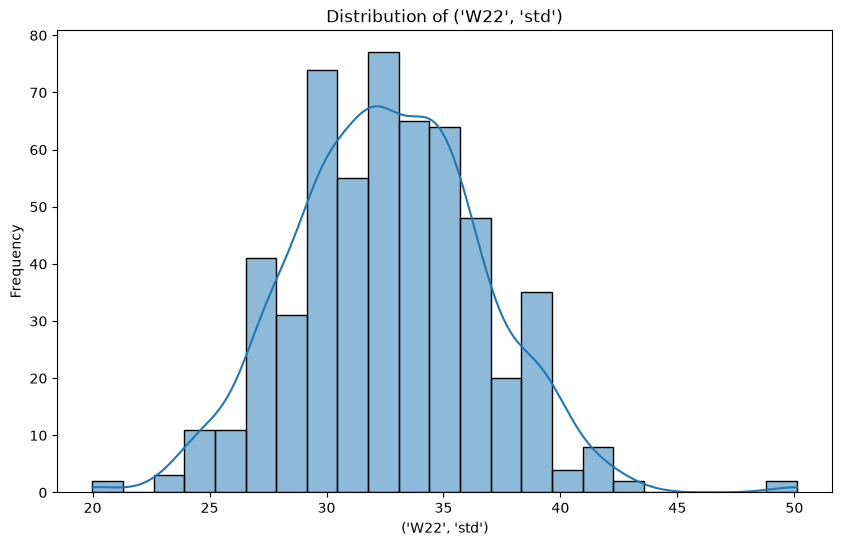

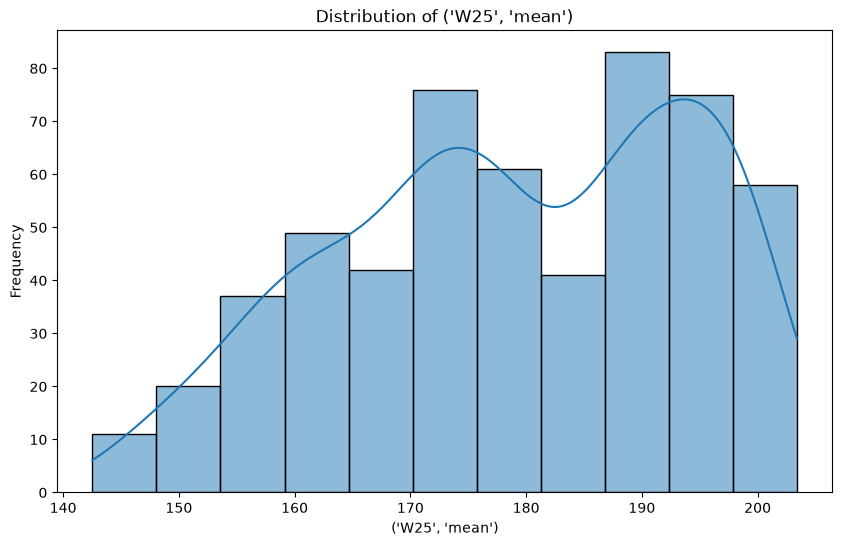

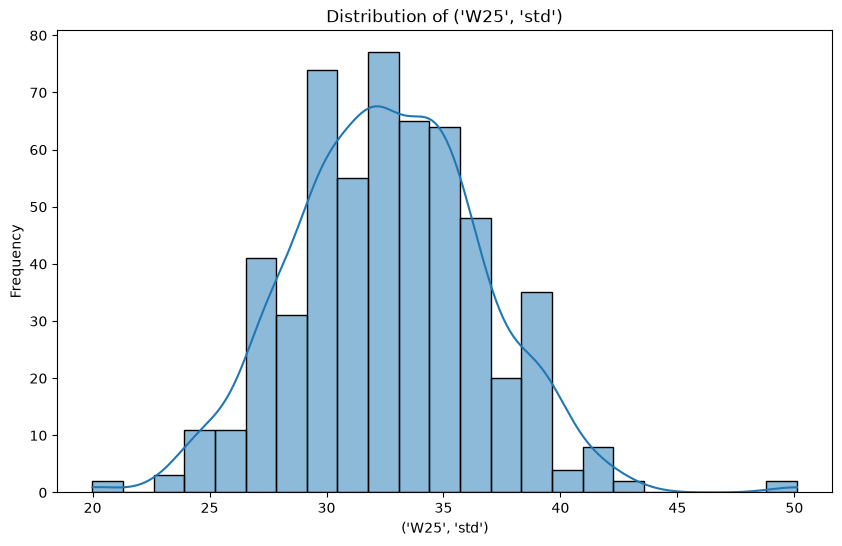

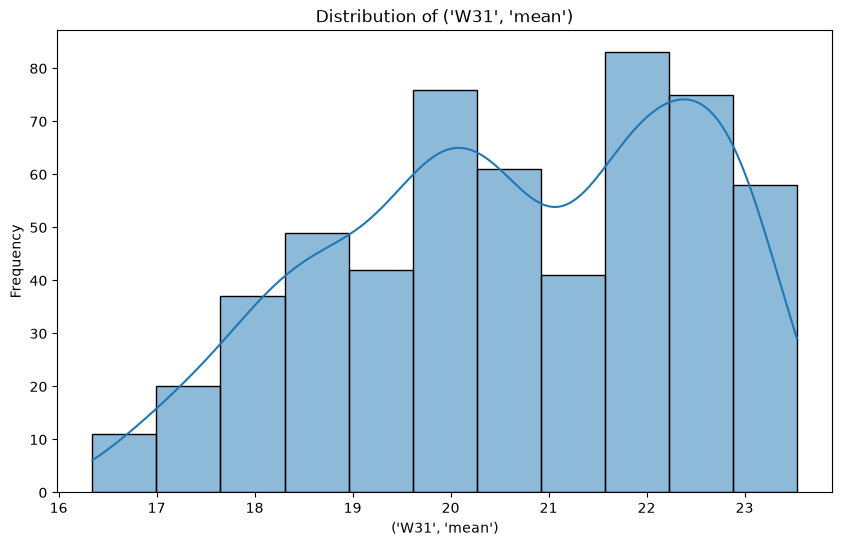

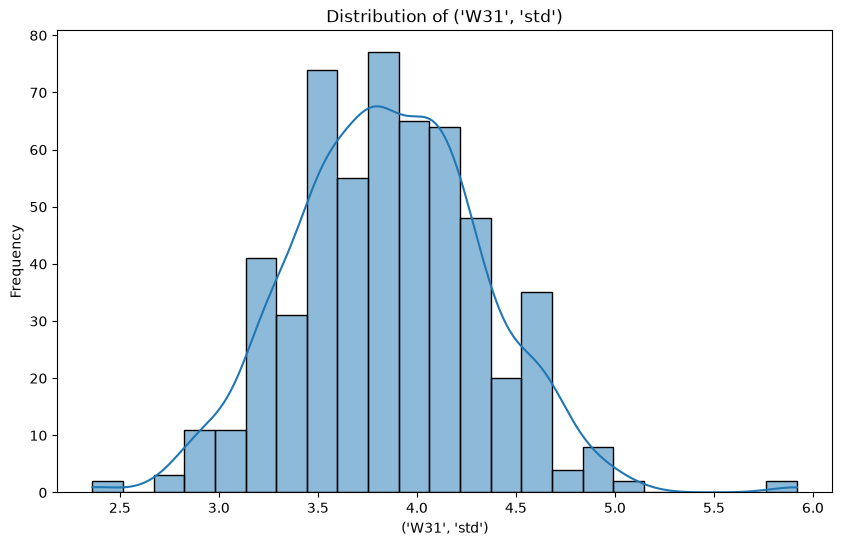

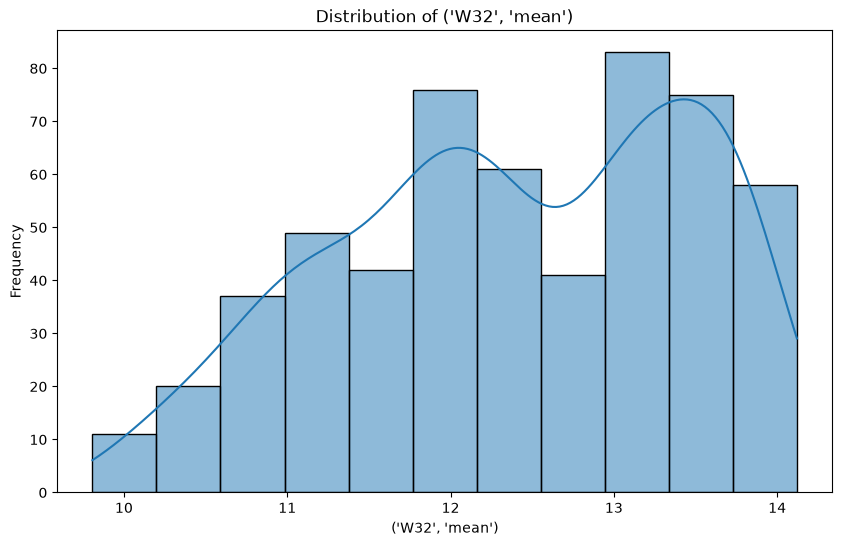

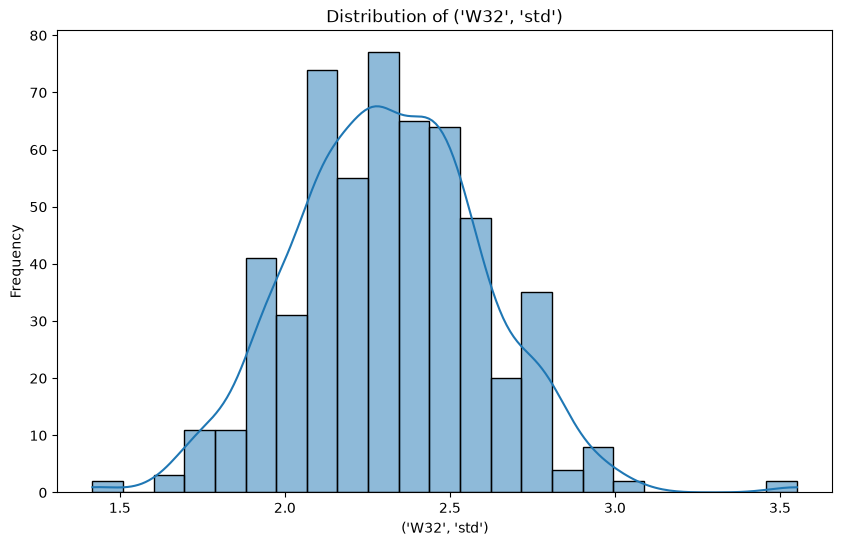

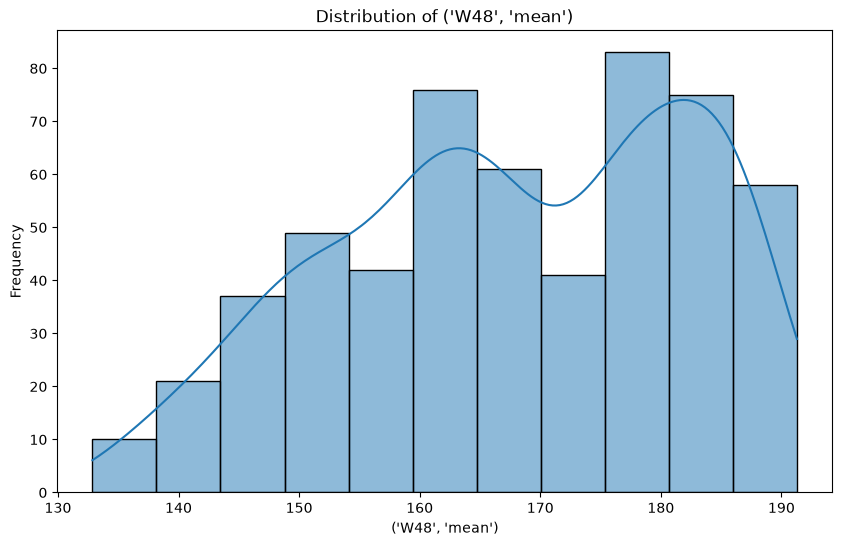

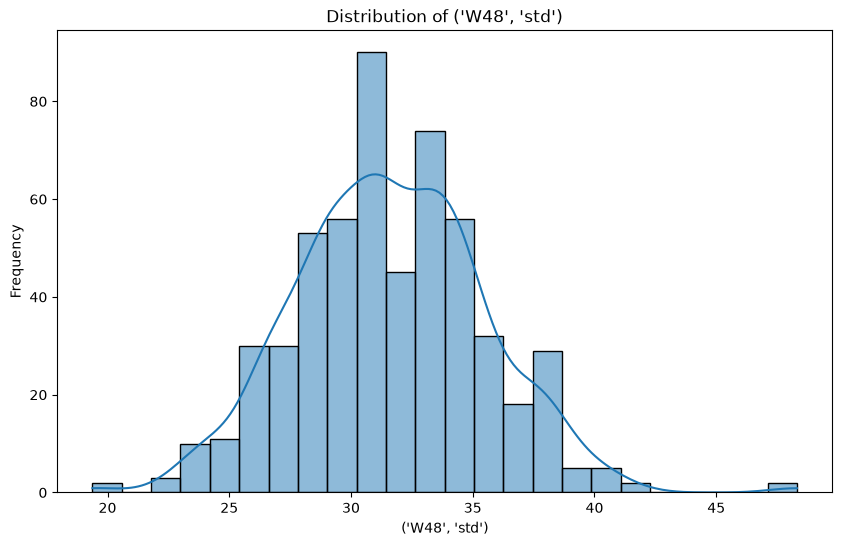

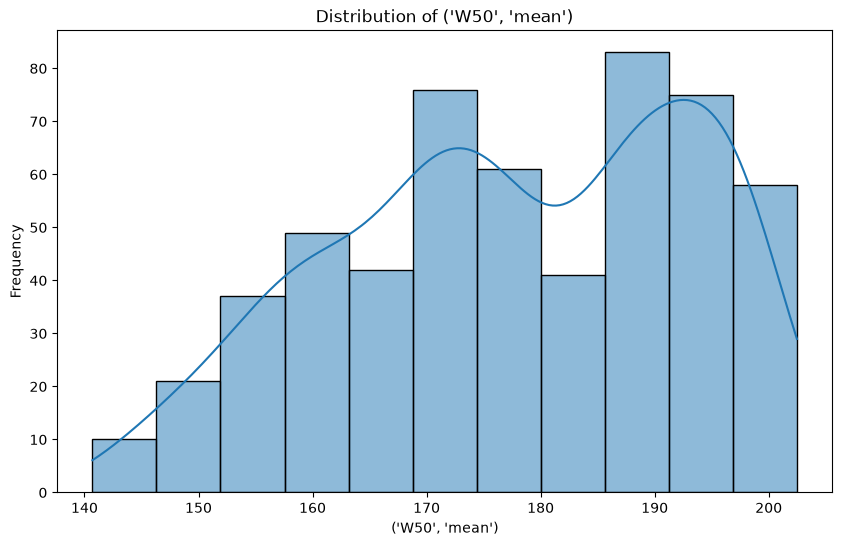

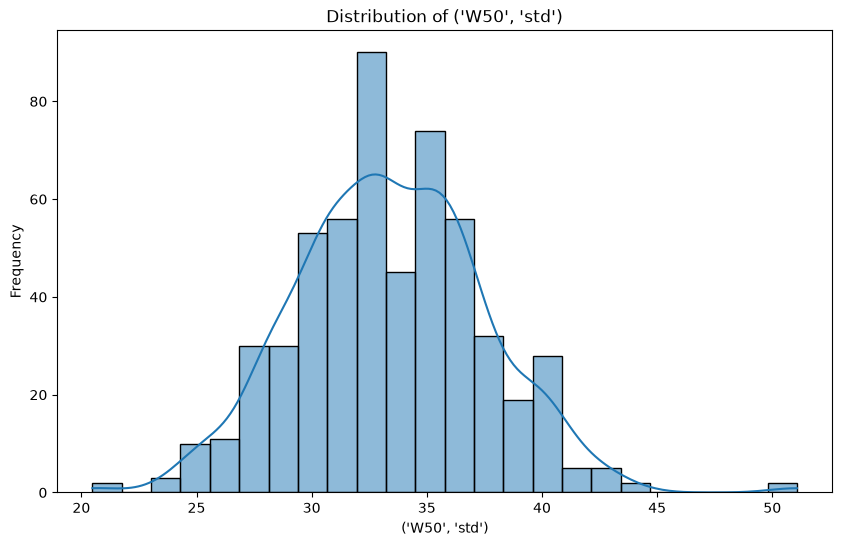

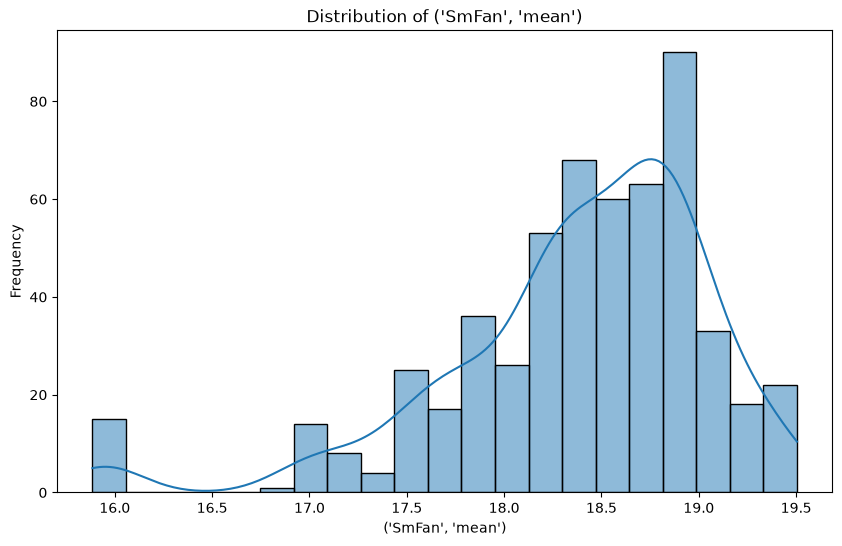

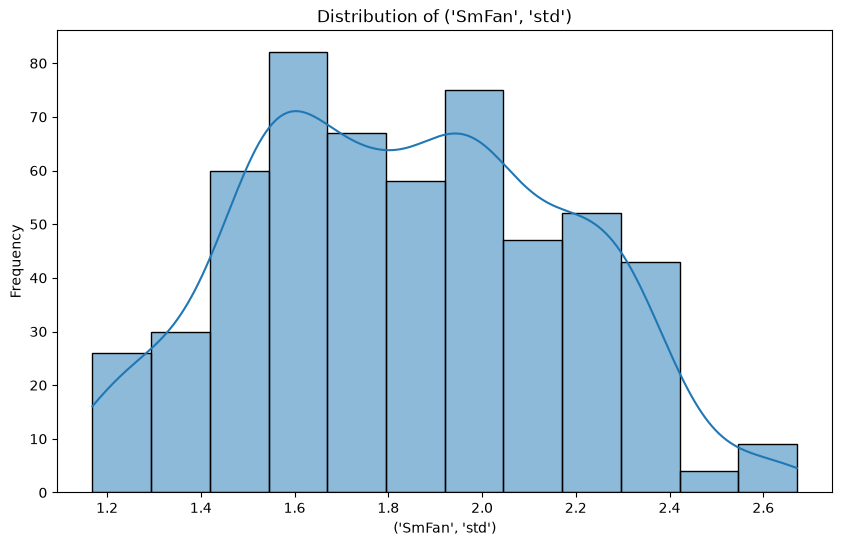

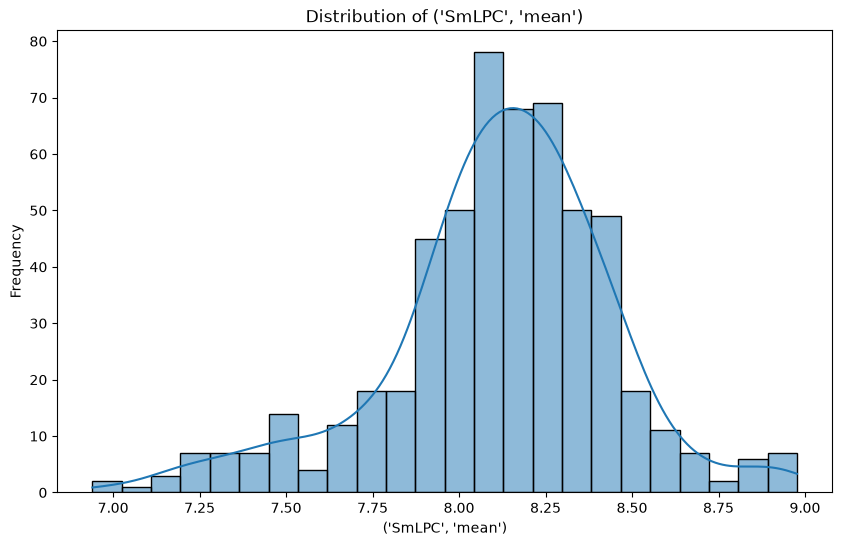

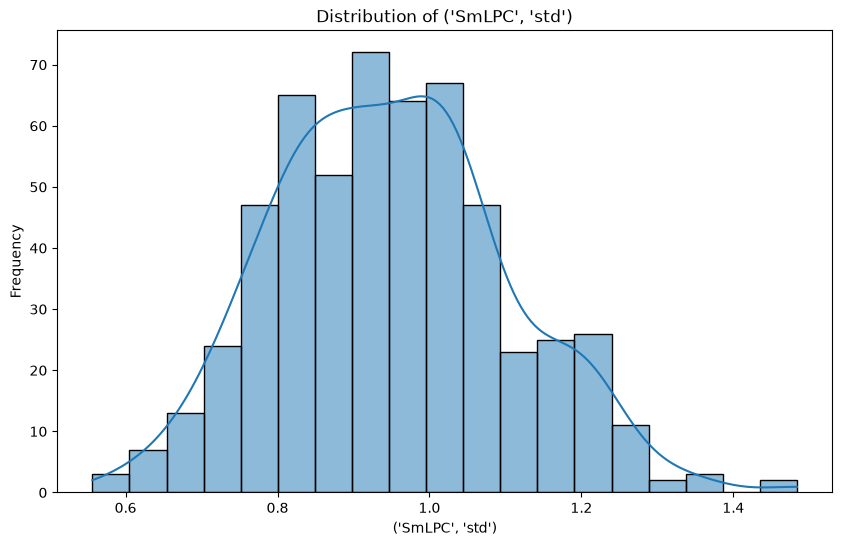

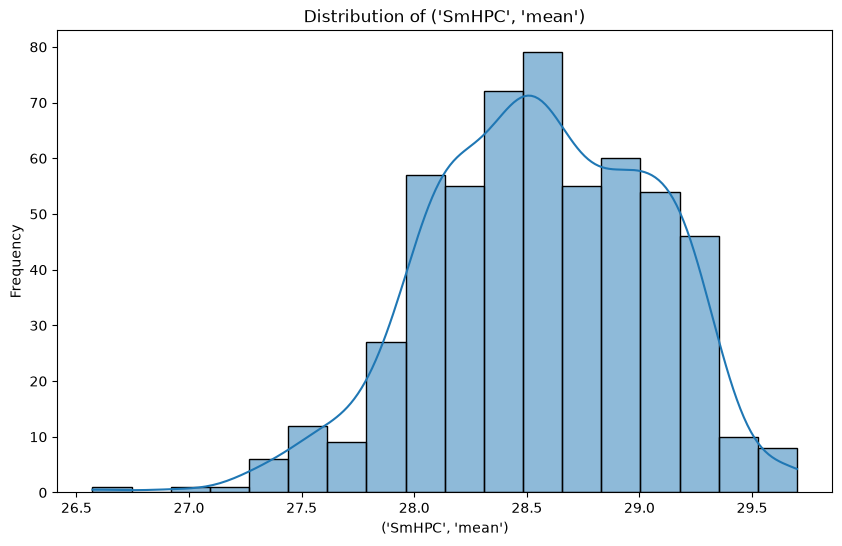

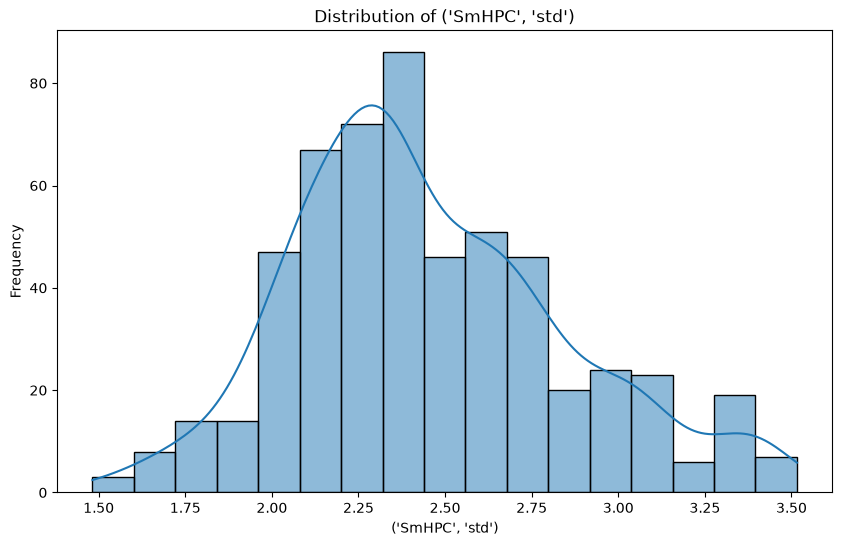

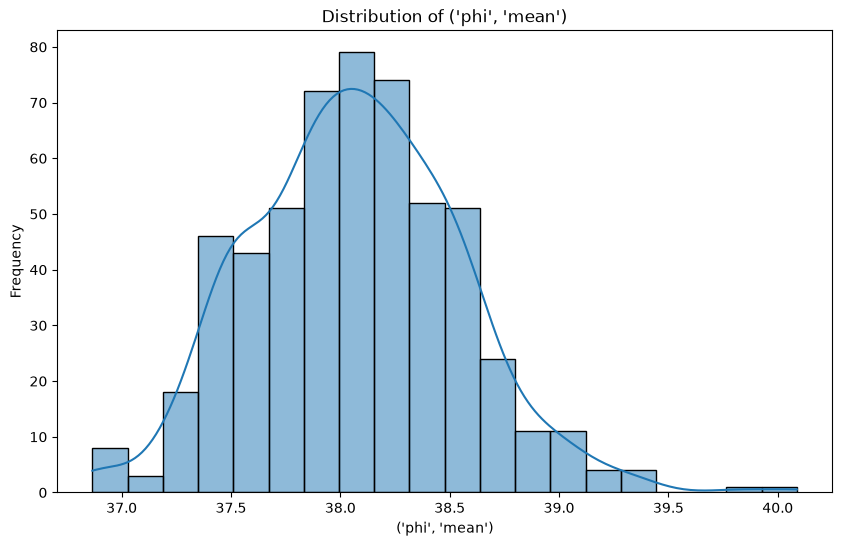

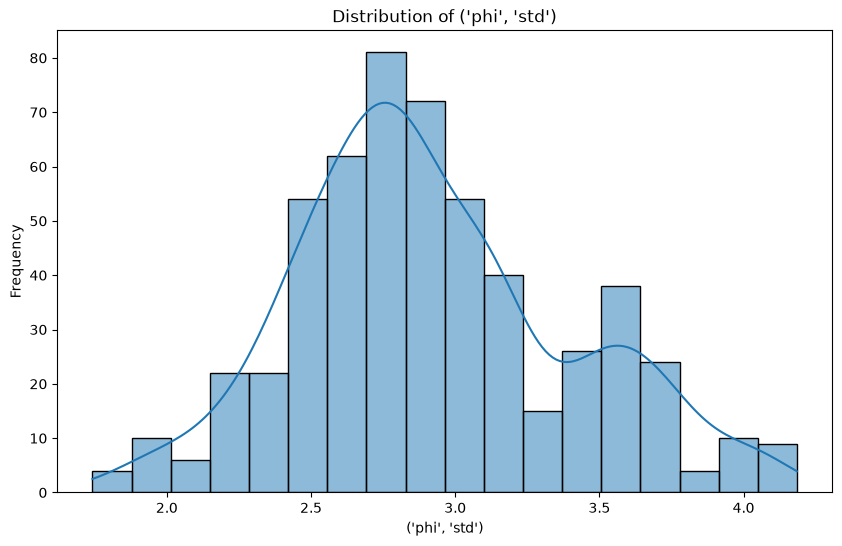

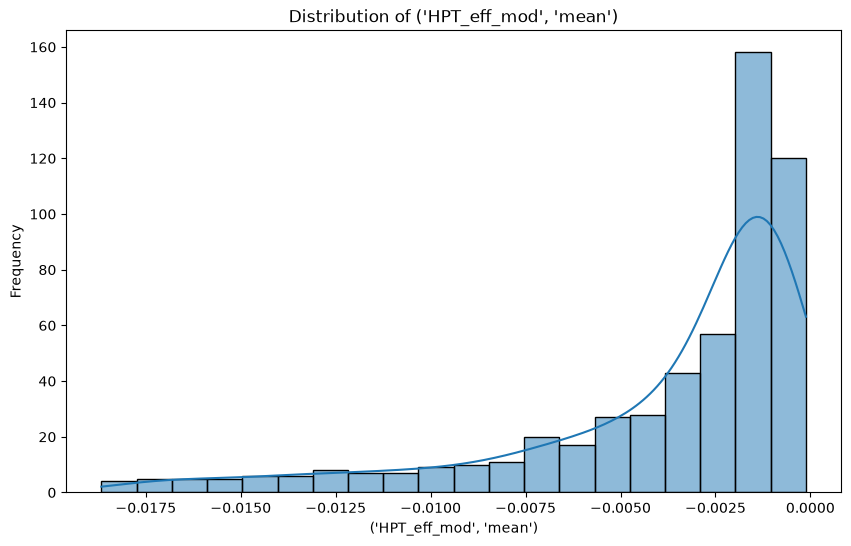

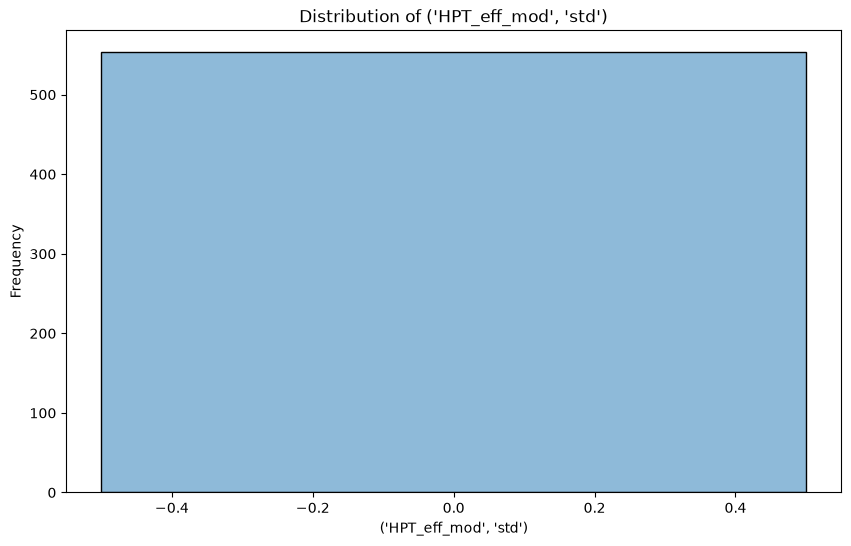

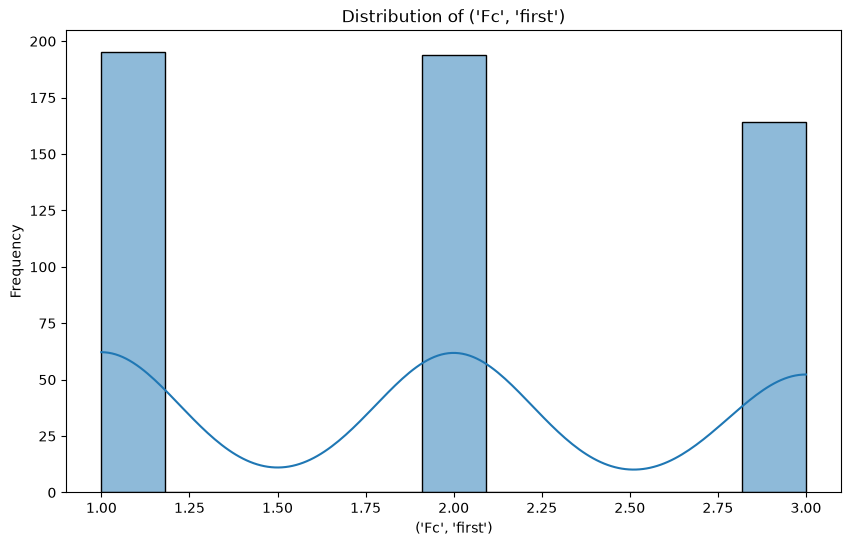

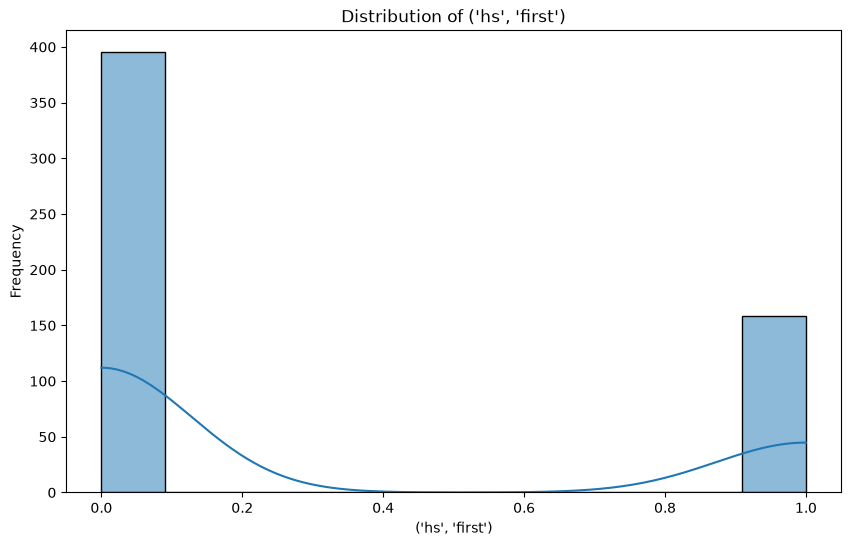

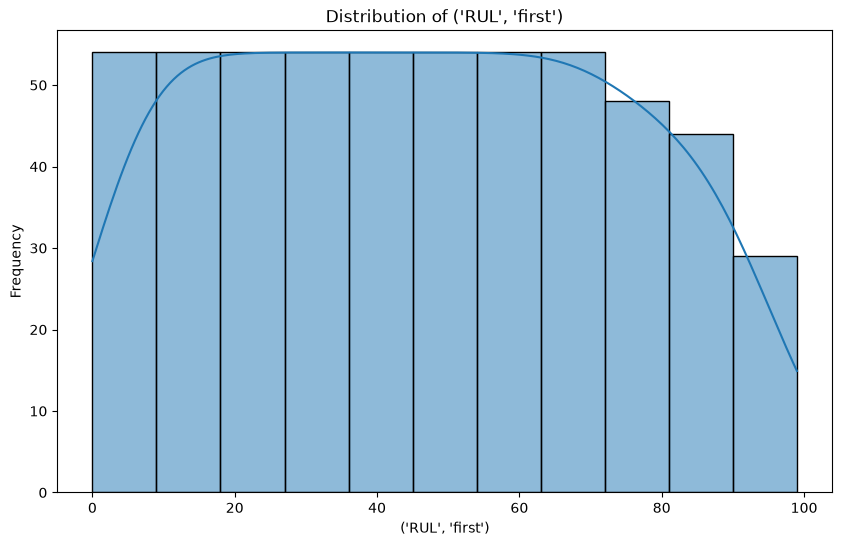

In [10]:
import seaborn as sns

for col in new_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(new_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(f"../docs/figs/Distribution_of_{col}after_combine_all_trips_based_on_unit_cycle.png", bbox_inches='tight')
    plt.show()

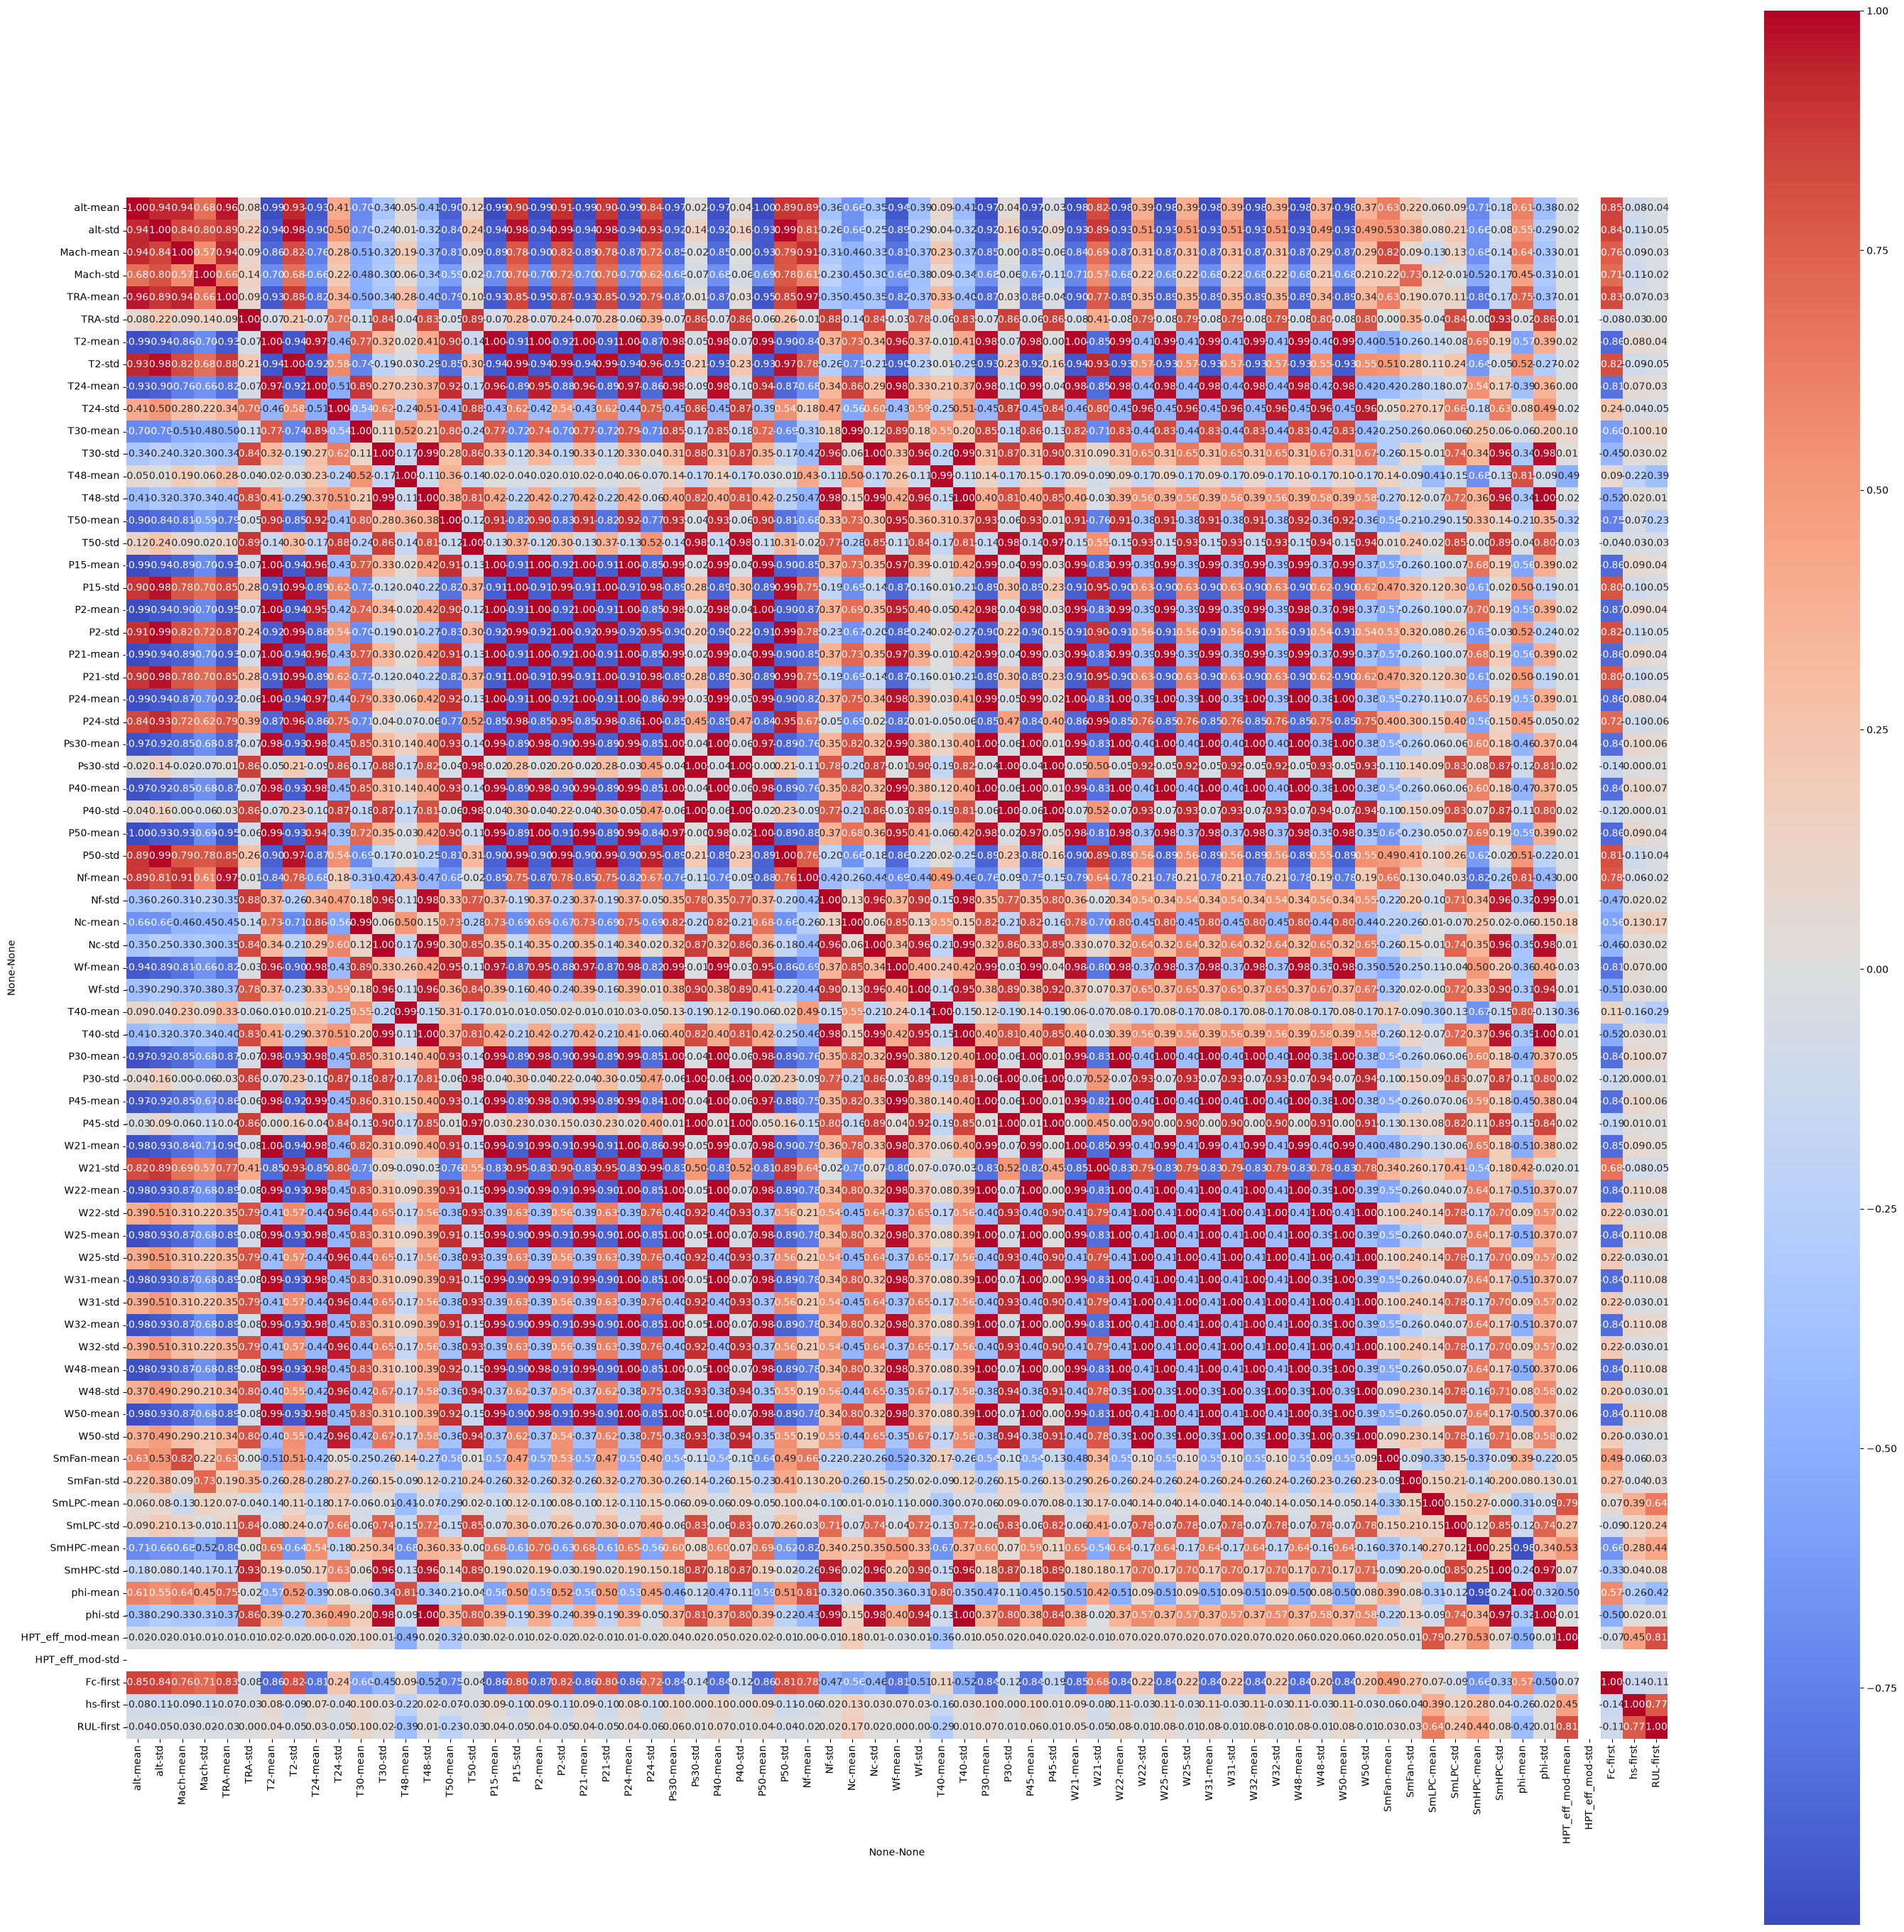

In [11]:
corr = new_df.corr()

plt.figure(figsize=(35, 35))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.savefig(f"../docs/figs/correlation_matrix_after_combine_all_trips_based_on_unit_and_cycle.png", bbox_inches='tight')
plt.show()

In [12]:
new_df.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in new_df.columns]

new_df.columns

Index(['alt_mean', 'alt_std', 'Mach_mean', 'Mach_std', 'TRA_mean', 'TRA_std',
       'T2_mean', 'T2_std', 'T24_mean', 'T24_std', 'T30_mean', 'T30_std',
       'T48_mean', 'T48_std', 'T50_mean', 'T50_std', 'P15_mean', 'P15_std',
       'P2_mean', 'P2_std', 'P21_mean', 'P21_std', 'P24_mean', 'P24_std',
       'Ps30_mean', 'Ps30_std', 'P40_mean', 'P40_std', 'P50_mean', 'P50_std',
       'Nf_mean', 'Nf_std', 'Nc_mean', 'Nc_std', 'Wf_mean', 'Wf_std',
       'T40_mean', 'T40_std', 'P30_mean', 'P30_std', 'P45_mean', 'P45_std',
       'W21_mean', 'W21_std', 'W22_mean', 'W22_std', 'W25_mean', 'W25_std',
       'W31_mean', 'W31_std', 'W32_mean', 'W32_std', 'W48_mean', 'W48_std',
       'W50_mean', 'W50_std', 'SmFan_mean', 'SmFan_std', 'SmLPC_mean',
       'SmLPC_std', 'SmHPC_mean', 'SmHPC_std', 'phi_mean', 'phi_std',
       'HPT_eff_mod_mean', 'HPT_eff_mod_std', 'Fc_first', 'hs_first',
       'RUL_first'],
      dtype='str')

In [13]:
new_df = new_df.reset_index()

In [14]:
new_df.shape[0]

553

In [15]:
new_df.columns

Index(['unit', 'cycle', 'alt_mean', 'alt_std', 'Mach_mean', 'Mach_std',
       'TRA_mean', 'TRA_std', 'T2_mean', 'T2_std', 'T24_mean', 'T24_std',
       'T30_mean', 'T30_std', 'T48_mean', 'T48_std', 'T50_mean', 'T50_std',
       'P15_mean', 'P15_std', 'P2_mean', 'P2_std', 'P21_mean', 'P21_std',
       'P24_mean', 'P24_std', 'Ps30_mean', 'Ps30_std', 'P40_mean', 'P40_std',
       'P50_mean', 'P50_std', 'Nf_mean', 'Nf_std', 'Nc_mean', 'Nc_std',
       'Wf_mean', 'Wf_std', 'T40_mean', 'T40_std', 'P30_mean', 'P30_std',
       'P45_mean', 'P45_std', 'W21_mean', 'W21_std', 'W22_mean', 'W22_std',
       'W25_mean', 'W25_std', 'W31_mean', 'W31_std', 'W32_mean', 'W32_std',
       'W48_mean', 'W48_std', 'W50_mean', 'W50_std', 'SmFan_mean', 'SmFan_std',
       'SmLPC_mean', 'SmLPC_std', 'SmHPC_mean', 'SmHPC_std', 'phi_mean',
       'phi_std', 'HPT_eff_mod_mean', 'HPT_eff_mod_std', 'Fc_first',
       'hs_first', 'RUL_first'],
      dtype='str')

Using one columns to solve multicolianarity problem

In [16]:
from sklearn.linear_model import LinearRegression

models = {}

targeted_cols = ["T50_mean", "T48_mean", "T40_mean", "phi_mean", "SmLPC_mean", "SmHPC_mean", "Ps30_mean", "P15_mean"]
X = new_df[["alt_mean", "Mach_mean", "TRA_mean"]]

predicted_results = pd.DataFrame()
processed_df = pd.DataFrame()

for col in targeted_cols :
    
    model = LinearRegression()
    model.fit(X, new_df[col])
    models[col] = model
    
    predicted_results[col] = model.predict(X)
    
for col in targeted_cols:
    processed_df[f"{col}_residual"] = new_df[col] - predicted_results[col]

processed_df["unit"] = new_df["unit"]
processed_df["cycle"] = new_df["cycle"]
processed_df["RUL"] = new_df["RUL_first"]
processed_df["Fc"] = new_df["Fc_first"]

In [17]:
residual_cols = [f"{col}_residual" for col in targeted_cols]
processed_df[residual_cols + ["RUL"]].corr()["RUL"]

T50_mean_residual     -0.803463
T48_mean_residual     -0.786299
T40_mean_residual     -0.754394
phi_mean_residual     -0.791618
SmLPC_mean_residual    0.797158
SmHPC_mean_residual    0.796878
Ps30_mean_residual     0.311214
P15_mean_residual     -0.055599
RUL                    1.000000
Name: RUL, dtype: float64

In [18]:
processed_df.shape

(553, 12)

In [19]:
processed_df.columns

Index(['T50_mean_residual', 'T48_mean_residual', 'T40_mean_residual',
       'phi_mean_residual', 'SmLPC_mean_residual', 'SmHPC_mean_residual',
       'Ps30_mean_residual', 'P15_mean_residual', 'unit', 'cycle', 'RUL',
       'Fc'],
      dtype='str')

#### ONE-HOT-Encoding for FC column

In [20]:
from sklearn.preprocessing import OneHotEncoder

# drop first column and use sparse false
encoder = OneHotEncoder(drop="first", sparse_output=False)

FC_df = encoder.fit_transform(processed_df[["Fc"]])
FC_df = pd.DataFrame(FC_df, columns=encoder.get_feature_names_out(["Fc"]))
final_df = pd.concat([processed_df, FC_df], axis=1)
final_df.drop(columns=["Fc"], inplace=True)
final_df.columns

Index(['T50_mean_residual', 'T48_mean_residual', 'T40_mean_residual',
       'phi_mean_residual', 'SmLPC_mean_residual', 'SmHPC_mean_residual',
       'Ps30_mean_residual', 'P15_mean_residual', 'unit', 'cycle', 'RUL',
       'Fc_2.0', 'Fc_3.0'],
      dtype='str')

In [21]:
final_df.columns

Index(['T50_mean_residual', 'T48_mean_residual', 'T40_mean_residual',
       'phi_mean_residual', 'SmLPC_mean_residual', 'SmHPC_mean_residual',
       'Ps30_mean_residual', 'P15_mean_residual', 'unit', 'cycle', 'RUL',
       'Fc_2.0', 'Fc_3.0'],
      dtype='str')

- Saving Training dataFrame

In [22]:
models

{'T50_mean': LinearRegression(),
 'T48_mean': LinearRegression(),
 'T40_mean': LinearRegression(),
 'phi_mean': LinearRegression(),
 'SmLPC_mean': LinearRegression(),
 'SmHPC_mean': LinearRegression(),
 'Ps30_mean': LinearRegression(),
 'P15_mean': LinearRegression()}

In [23]:
encoder

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreq

### Saving residual models and encoder

In [24]:
import pickle as pk

artifacts = {
    "residual_models": models,
    "fc_encoder": encoder
}

with open(r"../models/preprocessing_artifacts.pkl", "wb") as f:
    pk.dump(artifacts, f)
    

In [25]:
final_df.to_csv("../data/preprocessed/train_df.csv", index=False)

In [26]:
models

{'T50_mean': LinearRegression(),
 'T48_mean': LinearRegression(),
 'T40_mean': LinearRegression(),
 'phi_mean': LinearRegression(),
 'SmLPC_mean': LinearRegression(),
 'SmHPC_mean': LinearRegression(),
 'Ps30_mean': LinearRegression(),
 'P15_mean': LinearRegression()}

In [ ]:
from sklearn.preprocessing import OneHotEncoder


test_df = pd.read_csv("../data/cleaned/test_cleaned.csv")

exception_cols = ["unit", "cycle", "Fc", "hs", "RUL"]
first_cols = ["Fc", "hs", "RUL"]

targeted_cols = [col for col in test_df.columns if col not in exception_cols]

agg_dict = {}
for col in targeted_cols:
    agg_dict[col] = ["mean", "std"]
for col in first_cols:
    agg_dict[col] = ["first"]

new_test_df = test_df.groupby(["unit", "cycle"]).agg(agg_dict)

new_test_df.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in new_test_df.columns]
new_test_df = new_test_df.reset_index()


X = new_test_df[["alt_mean", "Mach_mean", "TRA_mean"]]
targeted_cols = ["T50_mean", "T48_mean", "T40_mean", "phi_mean", "SmLPC_mean", "SmHPC_mean", "Ps30_mean", "P15_mean"]

predicted_results = pd.DataFrame()
processed_test_df = pd.DataFrame()

for col in targeted_cols :
    
    model = models[col]
    predicted_results[col] = model.predict(X)
    
for col in targeted_cols:
    processed_test_df[f"{col}_residual"] = new_test_df[col] - predicted_results[col]
    
processed_test_df["unit"] = new_test_df["unit"]
processed_test_df["cycle"] = new_test_df["cycle"]
processed_test_df["RUL"] = new_test_df["RUL_first"]
processed_test_df["Fc"] = new_test_df["Fc_first"]

FC_test_df = encoder.transform(processed_test_df[["Fc"]])
FC_test_df = pd.DataFrame(FC_test_df, columns=encoder.get_feature_names_out(["Fc"]))

final_test_df = pd.concat([processed_test_df, FC_test_df], axis=1)
final_test_df.drop(columns=["Fc"], inplace=True)

final_test_df.to_csv("../data/preprocessed/test_df.csv", index=False)

## Preprocessing Summary

### Aggregation Level
Data was aggregated from the raw row level (per-flight-second sensor readings) to the **(unit, cycle) level**, since RUL is defined per cycle, not per instantaneous reading. Raw-level data showed heavy within-cycle variance (sawtooth patterns driven by climb/cruise/descent), which made row-level rolling windows meaningless. Aggregation reduced the dataset from ~4M rows to **553 rows** (train) and a corresponding row-per-cycle count for test.

### Aggregation Method
For each (unit, cycle) group:
- All physical/virtual sensor columns → `mean` and `std`
- `Fc`, `hs`, `RUL` → `first` (constant within a cycle)
- `unit`, `cycle` retained as groupby keys / identifiers, not aggregated

### Residual Correction
Raw sensor correlation with RUL was near-zero due to operating conditions (`alt`, `Mach`, `TRA`) dominating the variance. For each candidate sensor, a `LinearRegression` model was fit on `[alt_mean, Mach_mean, TRA_mean]` (train set only), and the residual (actual − predicted) was used as the feature instead of the raw value. This isolates the degradation-related signal from flight-condition noise.

**Models are fit once on train and reused via `.predict()` only on test — never refit on test data**, to avoid leakage between the two sets.

### Multicollinearity Resolution
Instead of PCA, one representative sensor was selected per correlated cluster, based on empirical residual-correlation strength with RUL (not just raw correlation):
- Thermal cluster (T40, T48, phi) → all three kept individually; each showed strong independent residual correlation (~0.75–0.79)
- Pressure/flow cluster (Ps30, P40, P30, P45, W21...W50) → **Ps30** selected (0.31 residual corr., clearly outperforming W21 at 0.03 in a direct comparison)
- Inlet pressure cluster (P15, P21, P2) → **P15** selected (weak residual corr., ~-0.06, kept as a baseline candidate for now)

### Categorical Feature: Fc
`Fc` (flight class) was added as a categorical feature via `OneHotEncoder(drop="first")`, producing two binary columns (`Fc_2.0`, `Fc_3.0`) with `Fc=1.0` as the reference category. The fitted encoder is reused (`.transform()` only, never refit) on the test set to guarantee identical columns between train and test.

### Final Feature Set
**Features (10 total):**
- 8 residual-corrected sensors: `T50_mean_residual, T48_mean_residual, T40_mean_residual, phi_mean_residual, SmLPC_mean_residual, SmHPC_mean_residual, Ps30_mean_residual, P15_mean_residual`
- 2 one-hot encoded flight-class indicators: `Fc_2.0, Fc_3.0`

**Identifiers (not used as model inputs, only for splitting):**
`unit, cycle`

**Target:**
`RUL`

**Excluded:** raw sensor values (superseded by residuals), `_std` columns (deferred to a future experiment), all θ degradation-modifier columns and `hs` (data leakage — derived from the same degradation model that defines RUL), `alt_mean/Mach_mean/TRA_mean` (used only as regression inputs to compute residuals, not as final features).

### Residual Correlation with RUL (train, after correction)
| Feature | Correlation |
|---|---|
| T50_mean_residual | -0.80 |
| phi_mean_residual | -0.79 |
| T48_mean_residual | -0.79 |
| SmLPC_mean_residual | +0.80 |
| SmHPC_mean_residual | +0.80 |
| T40_mean_residual | -0.75 |
| Ps30_mean_residual | +0.31 |
| P15_mean_residual | -0.06 |

### Output Artifacts
- `data/preprocessed/train_df.csv` — 553 rows, 13 columns (10 features + unit + cycle + RUL)
- `data/preprocessed/test_df.csv` — processed test set, identical schema, RUL confirmed complete (not censored) for this dataset release
- `models/preprocessing_artifacts.pkl` — dictionary containing the 8 fitted residual `LinearRegression` models plus the fitted `Fc` `OneHotEncoder`, all reused via `.predict()`/`.transform()` only on test

### Open Items Carried Forward
- Whether `_std` columns add predictive value (deferred experiment)
- Train/validation splitting strategy given the small fleet size (6 units) — resolved via LOUO-CV (see `train_model.ipynb`)